# ResNet-18 + DenseNet-121 Hybrid — Patient-Level Slicing

Restructured from the original slice-level-split version to follow the same **patient-level, 5-fold, One-vs-All (OvA)** protocol used in `Team_09_DAD_Net_Farida_Ali.ipynb` and `Team_09_ResNet50_Omar_Zayed.ipynb`. The model architecture (frozen ResNet-18 + frozen DenseNet-121 backbones feeding a BN-anchored MLP head, two-phase probe/fine-tune training) is unchanged from the original notebook — only the data splitting and evaluation protocol are fixed.

**What changed vs. the original notebook:**
- `sklearn.train_test_split` on individual slice paths (patients leak across train/val/test) → replaced with patient-level grouping, a leakage check, and a stratified **patient-level** hold-out test set.
- Single monolithic 3-class softmax classifier → **One-vs-All (OvA)**: three independent binary classifiers (AD vs REST, CN vs REST, MCI vs REST), each trained with patient-level 5-fold CV and combined into a validation-accuracy-weighted ensemble, matching Table III of the paper.
- Final multi-class prediction is obtained by comparing the three OvA positive-class scores per patient, not by a single softmax over 3 classes.

## Cell 1 — Kaggle Setup (Download ADNI Dataset)

In [1]:
import os, subprocess
from pathlib import Path

# ── Find AD/CN/MCI root ─────────────────────────────────────────────────────

GDRIVE_FILE_ID = '1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz'
WORK_DIR = Path('/kaggle/working')

TARGET_CLASSES = {'AD', 'CN', 'MCI'}

def find_adni_root(search_roots):
    """
    Check at most 2 levels deep (root itself, then its direct children).
    This avoids picking up the tensor-cache directory
    (/kaggle/working/preprocessed_*/train/AD …) which is 3 levels deep.
    """
    for sr in search_roots:
        sr = Path(sr)
        if not sr.exists():
            continue
        try:
            subdirs = {d for d in os.listdir(sr) if os.path.isdir(sr / d)}
            if TARGET_CLASSES.issubset(subdirs):
                return str(sr)
        except PermissionError:
            pass
        try:
            for sub in sorted(os.listdir(sr)):
                sub_path = sr / sub
                if not sub_path.is_dir():
                    continue
                try:
                    subdirs = {d for d in os.listdir(sub_path) if (sub_path / d).is_dir()}
                    if TARGET_CLASSES.issubset(subdirs):
                        return str(sub_path)
                except PermissionError:
                    pass
        except PermissionError:
            pass
    return None

# --- Search /kaggle/input first (Kaggle dataset attached via "Add Data") ---
ADNI_DIR = find_adni_root(['/kaggle/input/datasets/faridaali202301940/draftdata/adni_nifti_preprocessed'])

# --- Then /kaggle/working (previous gdown download) ---
if ADNI_DIR is None:
    ADNI_DIR = find_adni_root([WORK_DIR])

# --- Download if still not found ---
if ADNI_DIR is None:
    ADNI_ZIP_PATH = WORK_DIR / 'adni_dataset.zip'
    print('Dataset not found locally — downloading via gdown ...')
    subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
    import gdown
    gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', str(ADNI_ZIP_PATH), quiet=False)
    import zipfile
    with zipfile.ZipFile(str(ADNI_ZIP_PATH), 'r') as zf:
        zf.extractall(str(WORK_DIR))
    ADNI_ZIP_PATH.unlink(missing_ok=True)
    ADNI_DIR = find_adni_root([WORK_DIR])

if ADNI_DIR is None:
    raise RuntimeError(
        'Could not find a directory containing AD, CN, MCI subfolders.\n'
        'Options:\n'
        '  1. Add the Alzheimer dataset via Kaggle "Add Data" (fastest).\n'
        '  2. Set GDRIVE_FILE_ID to your own Google Drive zip.\n'
        '  3. Manually set ADNI_DIR below.'
    )

print(f'ADNI_DIR = {ADNI_DIR}')

for cls in sorted(TARGET_CLASSES):
    cls_path = os.path.join(ADNI_DIR, cls)
    n = sum(len(f) for _, _, f in os.walk(cls_path)) if os.path.isdir(cls_path) else 0
    print(f'  {cls}: ~{n} files')


ADNI_DIR = /kaggle/input/datasets/faridaali202301940/draftdata/adni_nifti_preprocessed
  AD: ~1434 files
  CN: ~2341 files
  MCI: ~4737 files


In [2]:
%pip install -q captum lime scikit-image shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 9.0 MB/s eta 0:00:00ta 0:00:01
Note: you may need to restart the kernel to use updated packages.


## Cell 2 — Imports, Seed & Device

In [3]:
import csv, json, random, shutil, os, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import seaborn as sns
from collections import Counter, defaultdict
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import (
    resnet18, ResNet18_Weights,
    densenet121, DenseNet121_Weights,
)

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_fscore_support, f1_score,
)

import torch._dynamo
torch._dynamo.config.suppress_errors = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Cell 3 — Configuration

In [4]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_ROOT  = ADNI_DIR
OUTPUT_DIR = '/kaggle/working/preprocessed_hybrid_rn18_dn121_patientlevel'
CKPT_DIR   = '/kaggle/working/checkpoints_hybrid_rn18_dn121_patientlevel'
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Data / splitting ─────────────────────────────────────────────────────────
IMAGE_SIZE      = 224
PREPROCESS_MODE = 'gray3'          # 'gray3' or 'rgb'
N_FOLDS         = 5
TEST_RATIO      = 0.15             # stratified, PATIENT-level hold-out
BATCH_SIZE      = 32
VALID_EXTS      = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

# ── Two-phase training budget (per fold, per binary task) ───────────────────
# NOTE: with 3 OvA classifiers x N_FOLDS folds x 2 phases, total training runs
# scale up fast. These epoch counts are deliberately smaller than the original
# single multi-class run; raise them if your compute budget allows.
PHASE_A_EPOCHS  = 8
PHASE_B_EPOCHS  = 15
PATIENCE        = 5
WARMUP_EPOCHS   = 2
LR_MIN          = 1e-6

# ── Discriminative LRs ───────────────────────────────────────────────────────
LR_HEAD_A      = 3e-3
LR_HEAD_B      = 1e-3
LR_BACKBONE_B  = 1e-4
WEIGHT_DECAY   = 5e-5
GRAD_CLIP_NORM = 1.0

# ── Head architecture ────────────────────────────────────────────────────────
HEAD_HIDDEN    = 384
HEAD_USE_BN    = True
DROPOUT        = 0.30

# ── Loss & label smoothing ───────────────────────────────────────────────────
LABEL_SMOOTHING       = 0.05
USE_CLASS_WEIGHTED_CE = True

# ── Augmentation ──────────────────────────────────────────────────────────────
USE_RANDAUGMENT = True
RANDAUG_N       = 2
RANDAUG_M       = 7
RANDOM_ERASING  = 0.20

# ── Test-time augmentation ───────────────────────────────────────────────────
TTA_HFLIP = True

# ── Backbone freeze (Phase B overrides to unfreeze last block) ───────────────
FREEZE_BACKBONES    = True
UNFREEZE_LAST_BLOCK = True

# ── XAI ───────────────────────────────────────────────────────────────────────
GRADCAM_TARGET   = 'resnet'        # 'resnet' or 'densenet'
SHAP_BG_SAMPLES  = 16
LIME_NUM_SAMPLES = 200

# ── ImageNet stats ────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d)) and d in ('AD', 'CN', 'MCI')
])
if not CLASS_NAMES:
    CLASS_NAMES = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])

print(f'Classes: {CLASS_NAMES} | IMAGE_SIZE={IMAGE_SIZE} | PREPROCESS_MODE={PREPROCESS_MODE}')
print(f'N_FOLDS={N_FOLDS} | TEST_RATIO={TEST_RATIO}')
print(f'Phase A={PHASE_A_EPOCHS} ep lr={LR_HEAD_A} | Phase B={PHASE_B_EPOCHS} ep lr_head={LR_HEAD_B} lr_bb={LR_BACKBONE_B}')
print(f'HEAD_HIDDEN={HEAD_HIDDEN} HEAD_USE_BN={HEAD_USE_BN} DROPOUT={DROPOUT} | USE_CLASS_WEIGHTED_CE={USE_CLASS_WEIGHTED_CE}')


Classes: ['AD', 'CN', 'MCI'] | IMAGE_SIZE=224 | PREPROCESS_MODE=gray3
N_FOLDS=5 | TEST_RATIO=0.15
Phase A=8 ep lr=0.003 | Phase B=15 ep lr_head=0.001 lr_bb=0.0001
HEAD_HIDDEN=384 HEAD_USE_BN=True DROPOUT=0.3 | USE_CLASS_WEIGHTED_CE=True


## Cell 4 — Build Patient Map

In [5]:
patient_classes = defaultdict(set)
patient_slices  = defaultdict(list)

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_dir):
        print(f"[WARNING] Missing class folder: {cls_dir}")
        continue
    for patient_id in os.listdir(cls_dir):
        patient_dir = os.path.join(cls_dir, patient_id)
        if not os.path.isdir(patient_dir):
            continue
        slices = [
            os.path.join(patient_dir, f)
            for f in os.listdir(patient_dir)
            if os.path.splitext(f)[1].lower() in VALID_EXTS
        ]
        if slices:
            patient_classes[patient_id].add(cls)
            patient_slices[(patient_id, cls)].extend(slices)

print(f"Total unique patients: {len(patient_classes)}")
if len(patient_classes) == 0:
    raise RuntimeError(
        f"No patient subfolders found under {DATA_ROOT}/<class>/<patient_id>/*.\n"
        "This dataset layout is required for patient-level splitting. If your class "
        "folders contain slice files directly (no patient subfolder), patient-level "
        "grouping is not possible without re-exporting the dataset with patient IDs preserved."
    )


Total unique patients: 320


## Cell 5 — Leakage Check & Clean Patient Map

In [6]:
# ── Leakage check: exclude patients appearing in more than one class ──────────
leakage_patients = {
    pid: classes
    for pid, classes in patient_classes.items()
    if len(classes) > 1
}

print(f"\n{'='*55}")
print(f"  LEAKAGE CHECK")
print(f"{'='*55}")
if leakage_patients:
    print(f"  Patients in multiple classes (EXCLUDED): {len(leakage_patients)}")
    for pid, classes in sorted(leakage_patients.items()):
        print(f"    {pid}  ->  {sorted(classes)}")
else:
    print("  No patients in multiple classes. Dataset is clean.")

clean_patients = {
    pid: list(classes)[0]
    for pid, classes in patient_classes.items()
    if pid not in leakage_patients
}
print(f"\n  Patients kept    : {len(clean_patients)}")
print(f"  Patients excluded: {len(leakage_patients)}")



  LEAKAGE CHECK
  No patients in multiple classes. Dataset is clean.

  Patients kept    : 320
  Patients excluded: 0


## Cell 6 — Stratified Hold-Out Test Set (Patient-Level)

In [7]:
class_patients = defaultdict(list)
for pid, cls in clean_patients.items(): class_patients[cls].append(pid)
for cls in CLASS_NAMES: random.shuffle(class_patients[cls])

test_patients, trainval_patients = [], []
print('='*60); print('  HOLD-OUT TEST SET (stratified, patient-level)'); print('='*60)
for cls in CLASS_NAMES:
    pids = class_patients[cls]
    n_test = max(1, int(len(pids) * TEST_RATIO))
    test_patients.extend(pids[:n_test]); trainval_patients.extend(pids[n_test:])
    print(f'  {cls:<6}: {len(pids):>4} total | test={n_test} | trainval={len(pids)-n_test}')

assert not (set(test_patients) & set(trainval_patients)), 'Patient overlap between test and trainval!'
print(f'  Test patients: {len(test_patients)} | Train+Val patients: {len(trainval_patients)}')

test_entries = []
for pid in test_patients:
    cls = clean_patients[pid]; label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]: test_entries.append((path, label, pid))
print(f'  Test slices: {len(test_entries)}')


  HOLD-OUT TEST SET (stratified, patient-level)
  AD    :   54 total | test=8 | trainval=46
  CN    :   88 total | test=13 | trainval=75
  MCI   :  178 total | test=26 | trainval=152
  Test patients: 47 | Train+Val patients: 273
  Test slices: 1261


## Cell 7 — Preprocess & Cache All Slices

Images resized to **224x224** (`PREPROCESS_MODE='gray3'`: grayscale, replicated to 3 channels — matches the ImageNet-pretrained ResNet-18/DenseNet-121 input format), saved as uint8 `.pt` tensors keyed by `patient_id + filename` so a slice can always be traced back to its patient during evaluation.

In [8]:
if os.path.exists(OUTPUT_DIR): shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_entries = []
for pid, cls in clean_patients.items():
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]: all_entries.append((path, label, pid))

fname_counts = {}

def preprocess_and_save(entries, desc='Preprocessing'):
    for path, label, pid in tqdm(entries, desc=desc):
        cls_name = CLASS_NAMES[label]
        out_dir  = os.path.join(OUTPUT_DIR, cls_name)
        os.makedirs(out_dir, exist_ok=True)
        base = os.path.splitext(os.path.basename(path))[0]
        key  = f'{pid}_{base}'.replace('/', '_').replace('\\', '_')
        fname_counts[key] = fname_counts.get(key, 0) + 1
        suffix   = f'_dup{fname_counts[key]}' if fname_counts[key] > 1 else ''
        out_path = os.path.join(out_dir, f'{key}{suffix}.pt')
        if not os.path.exists(out_path):
            if PREPROCESS_MODE == 'rgb':
                img    = Image.open(path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
                tensor = (transforms.ToTensor()(img) * 255).byte()
            elif PREPROCESS_MODE == 'gray3':
                img    = Image.open(path).convert('L').resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
                tensor = (transforms.ToTensor()(img) * 255).byte().repeat(3, 1, 1)
            else:
                raise ValueError("PREPROCESS_MODE must be 'rgb' or 'gray3'")
            torch.save(tensor, out_path)

preprocess_and_save(all_entries, desc='Preprocessing')
print(f'Done. {len(all_entries)} slices cached.')

pt_lookup = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_dir): continue
    for fname in os.listdir(cls_dir):
        if fname.endswith('.pt'): pt_lookup[fname[:-3]] = os.path.join(cls_dir, fname)
print(f'pt_lookup: {len(pt_lookup)} entries')


Preprocessing: 100%|██████████| 8512/8512 [01:01<00:00, 138.11it/s]

Done. 8512 slices cached.
pt_lookup: 8512 entries


## Cell 8 — Dataset Class & Augmentation

Same augmentation recipe as the original notebook (RandAugment + ColorJitter + RandomErasing + horizontal flip), applied on the fly to cached uint8 tensors. `SliceDataset` now threads the **patient ID** through `__getitem__` so predictions can be aggregated per patient at evaluation time.

In [9]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

_rand_aug = transforms.RandAugment(num_ops=RANDAUG_N, magnitude=RANDAUG_M) if USE_RANDAUGMENT else None
_erasing  = transforms.RandomErasing(p=RANDOM_ERASING, scale=(0.02, 0.12)) if RANDOM_ERASING > 0 else None

def apply_train_augment(t_byte):
    """t_byte: uint8 tensor (3, H, W). Returns float (3, H, W), normalized."""
    t = t_byte.clone()
    t = transforms.RandomHorizontalFlip(p=0.5)(t)
    if _rand_aug is not None:
        t = _rand_aug(t)
    t = t.float() / 255.0
    t = transforms.ColorJitter(brightness=0.15, contrast=0.15)(t)
    t = normalize(t)
    if _erasing is not None:
        t = _erasing(t)
    return t

class SliceDataset(Dataset):
    def __init__(self, entries, augment=False):
        self.augment = augment; self.samples = []
        for path, label, pid in entries:
            base = os.path.splitext(os.path.basename(path))[0]
            key  = f'{pid}_{base}'.replace('/', '_').replace('\\', '_')
            if key in pt_lookup:
                self.samples.append((pt_lookup[key], label, pid))
            else:
                for dup in range(2, 50):
                    dk = f'{key}_dup{dup}'
                    if dk in pt_lookup: self.samples.append((pt_lookup[dk], label, pid)); break

    def __len__(self):  return len(self.samples)
    def get_labels(self): return [s[1] for s in self.samples]

    def __getitem__(self, idx):
        pt_path, label, pid = self.samples[idx]
        t = torch.load(pt_path, weights_only=True)
        if self.augment:
            return apply_train_augment(t), label, pid
        return normalize(t.float() / 255.0), label, pid

print('SliceDataset defined (patient-ID aware).')


SliceDataset defined (patient-ID aware).


## Cell 9 — ResNet-18 + DenseNet-121 Hybrid Architecture

Unchanged from the original notebook: frozen ImageNet-pretrained ResNet-18 (512-D) and DenseNet-121 (1024-D) feature extractors, concatenated and fed to a BatchNorm-anchored MLP head. `build_hybrid(num_classes=2)` is called fresh for every fold of every OvA binary task.

In [10]:
def _make_head(in_dim, hidden, num_classes, dropout, use_bn):
    """BN-anchored MLP head. BatchNorm1d compensates BN-eval mismatch on MRI features."""
    layers = [nn.Dropout(dropout)]
    hh = int(hidden) if hidden else 0
    if hh > 0:
        layers += [nn.Linear(in_dim, hh)]
        if use_bn:
            layers += [nn.BatchNorm1d(hh)]
        layers += [nn.GELU(),
                   nn.Dropout(max(0.0, dropout * 0.5)),
                   nn.Linear(hh, num_classes)]
    else:
        layers += [nn.Linear(in_dim, num_classes)]
    return nn.Sequential(*layers)

class ResNetDenseNetHybrid(nn.Module):
    """Frozen ResNet-18 (512-D) + frozen DenseNet-121 (1024-D) → trainable head."""
    def __init__(self, num_classes, dropout=0.30, head_hidden=384, head_use_bn=True,
                 freeze_backbones=True):
        super().__init__()
        r = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        r.fc = nn.Identity()
        d = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        d.classifier = nn.Identity()
        self.resnet   = r
        self.densenet = d
        if freeze_backbones:
            for p in self.resnet.parameters():   p.requires_grad = False
            for p in self.densenet.parameters(): p.requires_grad = False
        self.head = _make_head(512 + 1024, head_hidden, num_classes, dropout, head_use_bn)

    def forward(self, x):
        return self.head(torch.cat([self.resnet(x), self.densenet(x)], dim=1))

def build_hybrid(num_classes: int) -> nn.Module:
    return ResNetDenseNetHybrid(
        num_classes, dropout=DROPOUT, head_hidden=HEAD_HIDDEN, head_use_bn=HEAD_USE_BN,
        freeze_backbones=FREEZE_BACKBONES,
    )

_probe = build_hybrid(2)
total_p = sum(p.numel() for p in _probe.parameters())
train_p = sum(p.numel() for p in _probe.parameters() if p.requires_grad)
print(f'Hybrid model — total params: {total_p:,} | trainable (head only, Phase A): {train_p:,}')
del _probe

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 87.2MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 152MB/s] 

Hybrid model — total params: 18,722,114 | trainable (head only, Phase A): 591,746


## Cell 10 — Two-Phase Training Utilities (Probe + Fine-tune)

Phase A trains only the MLP head (backbones frozen). Phase B additionally unfreezes `resnet.layer4` and `densenet.features.denseblock4`/`norm5` with a smaller discriminative LR. This logic is unchanged from the original notebook; `run_epoch` and `patient_level_eval` are adapted to carry the patient ID through each batch (needed for patient-level aggregation) and `patient_level_eval` supports the same horizontal-flip TTA used at final test time.

In [15]:
# ── Freeze / unfreeze helpers ────────────────────────────────────────────────
def freeze_all_but_head(model):
    """Phase A: only head is trainable."""
    for p in model.parameters(): p.requires_grad = False
    for p in model.head.parameters(): p.requires_grad = True

def unfreeze_last_blocks(model):
    """Phase B: additionally unfreeze last residual/dense block."""
    for p in model.resnet.layer4.parameters():                 p.requires_grad = True
    for p in model.densenet.features.denseblock4.parameters(): p.requires_grad = True
    for p in model.densenet.features.norm5.parameters():       p.requires_grad = True

def set_probe_training_mode(model, training: bool, phase_b: bool = False):
    """Keep frozen BN in eval(); only trainable sub-modules go to train()."""
    if not training:
        model.eval(); return
    model.train()
    model.resnet.eval()
    model.densenet.eval()
    if phase_b:
        model.resnet.layer4.train(True)
        model.densenet.features.denseblock4.train(True)
        model.densenet.features.norm5.train(True)
    model.head.train(True)

# ── Optimizer with discriminative LRs ───────────────────────────────────────
def build_optimizer(model, lr_head, lr_backbone=None):
    head_ids    = {id(p) for p in model.head.parameters()}
    head_params = list(model.head.parameters())
    back_params = [p for p in model.parameters() if p.requires_grad and id(p) not in head_ids]
    groups = [{'params': head_params, 'lr': lr_head}]
    if back_params and lr_backbone:
        groups.append({'params': back_params, 'lr': lr_backbone})
    return optim.AdamW(groups, weight_decay=WEIGHT_DECAY)

# ── Cosine LR + warmup (per-epoch step) ─────────────────────────────────────
def cosine_with_warmup(optimizer, total_epochs, warmup):
    for g in optimizer.param_groups:
        g['initial_lr'] = g['lr']
    def lr_lambda(epoch):
        if epoch < warmup:
            return (epoch + 1) / max(1, warmup)
        progress = (epoch - warmup) / max(1, total_epochs - warmup)
        return max(LR_MIN / optimizer.param_groups[0]['initial_lr'],
                   0.5 * (1.0 + math.cos(math.pi * progress)))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Core epoch runner (patient-ID aware) ─────────────────────────────────────
def run_epoch(loader, model, criterion, optimizer=None, scaler=None, desc='', phase_b=False):
    is_train = optimizer is not None
    set_probe_training_mode(model, is_train, phase_b=phase_b)
    dev_type   = 'cuda' if device.type == 'cuda' else 'cpu'
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels, _pids in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=dev_type, enabled=(device.type == 'cuda')):
                outputs = model(images)
                loss    = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                if GRAD_CLIP_NORM and GRAD_CLIP_NORM > 0:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(
                        [p for p in model.parameters() if p.requires_grad], GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total      += labels.size(0)
    return total_loss / max(total, 1), correct / max(total, 1)

def patient_level_eval(loader, model, num_classes=2, use_tta=False):
    """Aggregates slice-level softmax probabilities per patient (mean), then argmax."""
    model.to(device).eval()
    dev_type = 'cuda' if device.type == 'cuda' else 'cpu'
    patient_probs  = defaultdict(lambda: np.zeros(num_classes))
    patient_labels = {}
    with torch.no_grad():
        for images, labels, pids in tqdm(loader, desc='Patient-eval', leave=False):
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=dev_type, enabled=(device.type == 'cuda')):
                logits = model(images)
                if use_tta:
                    logits = logits + model(torch.flip(images, dims=[-1]))
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            for prob, lbl, pid in zip(probs, labels.numpy(), pids):
                patient_probs[pid] += prob; patient_labels[pid] = int(lbl)
    all_true, all_pred = [], []
    for pid, ps in patient_probs.items():
        all_true.append(patient_labels[pid]); all_pred.append(int(np.argmax(ps)))
    return float(np.mean(np.array(all_true) == np.array(all_pred))), all_true, all_pred

# ── Single-phase train loop (used by both Phase A and Phase B) ──────────────
def train_phase(model, optimizer, scheduler, n_epochs, ckpt_path, phase_name, best_acc_in, phase_b=False,
                train_loader=None, val_loader=None, criterion=None):
    scaler       = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    best_acc     = best_acc_in
    patience_ctr = 0
    history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    for epoch in range(1, n_epochs + 1):
        tl, ta = run_epoch(train_loader, model, criterion, optimizer, scaler,
                           desc=f'{phase_name} ep{epoch}/{n_epochs} [train]', phase_b=phase_b)
        vl, va = run_epoch(val_loader, model, criterion,
                           desc=f'{phase_name} ep{epoch}/{n_epochs} [val]', phase_b=phase_b)
        cur_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va); history['lr'].append(cur_lr)
        scheduler.step()
        print(f'  {phase_name} Ep {epoch:02d} | lr={cur_lr:.2e} | train loss={tl:.4f} acc={ta*100:.1f}%'
              f' | val loss={vl:.4f} acc={va*100:.1f}%')
        if va > best_acc + 1e-5:
            best_acc = va; patience_ctr = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f'    * Best val_acc={best_acc*100:.2f}% -- saved.')
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'    Early stopping at epoch {epoch}.'); break
    return history, best_acc

def train_two_phase(model, name, ckpt_path, train_loader, val_loader, criterion):
    """Phase A: probe (head only). Phase B: unfreeze last block + fine-tune. Returns best val acc."""
    freeze_all_but_head(model)
    opt_a   = build_optimizer(model, LR_HEAD_A)
    sched_a = cosine_with_warmup(opt_a, PHASE_A_EPOCHS, WARMUP_EPOCHS)
    hist_a, best_acc = train_phase(model, opt_a, sched_a, PHASE_A_EPOCHS, ckpt_path,
                                   f'{name} / Phase A', 0.0, phase_b=False,
                                   train_loader=train_loader, val_loader=val_loader, criterion=criterion)

    hist_b = None
    if UNFREEZE_LAST_BLOCK:
        model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
        unfreeze_last_blocks(model)
        opt_b   = build_optimizer(model, LR_HEAD_B, LR_BACKBONE_B)
        sched_b = cosine_with_warmup(opt_b, PHASE_B_EPOCHS, WARMUP_EPOCHS)
        hist_b, best_acc = train_phase(model, opt_b, sched_b, PHASE_B_EPOCHS, ckpt_path,
                                       f'{name} / Phase B', best_acc, phase_b=True,
                                       train_loader=train_loader, val_loader=val_loader, criterion=criterion)

    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    model.to(device).eval()
    return {'phase_a': hist_a, 'phase_b': hist_b}, best_acc

print('Training utilities defined.')

Training utilities defined.


## Cell 11 — K-Fold Cross-Validation: 1-vs-All Binary Classifiers (Two-Phase per Fold)

For each of the 3 OvA tasks (AD-vs-REST, CN-vs-REST, MCI-vs-REST), the **train+val patient pool** is split into `N_FOLDS` patient-disjoint folds. For each fold: build the hybrid model fresh, run Phase A (probe) then Phase B (fine-tune last block), and record the patient-level validation accuracy of the best checkpoint. All patients in a fold's slices come from the same partition — no patient ever appears in both train and val within a fold.


  AD vs REST  --  5-Fold CV  (ResNet18+DenseNet121 Hybrid)

  --- Fold 1/5 ---
  Train -- AD: 961 | REST: 4807 | Val patients: 56


  AD vs REST -- Fold 1 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.7099 acc=60.6% | val loss=0.6348 acc=74.0%
    * Best val_acc=73.97% -- saved.


  AD vs REST -- Fold 1 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6960 acc=63.7% | val loss=0.7052 acc=71.4%


  AD vs REST -- Fold 1 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6560 acc=66.1% | val loss=0.6647 acc=72.7%


  AD vs REST -- Fold 1 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6460 acc=68.1% | val loss=0.7015 acc=73.0%


...

  AD vs REST -- Fold 1 / Phase B Ep 11 | lr=3.23e-04 | train loss=0.2639 acc=98.2% | val loss=0.7544 acc=80.6%


  AD vs REST -- Fold 1 / Phase B Ep 12 | lr=2.16e-04 | train loss=0.2526 acc=98.8% | val loss=0.7316 acc=81.2%
    * Best val_acc=81.19% -- saved.


  AD vs REST -- Fold 1 / Phase B Ep 13 | lr=1.26e-04 | train loss=0.2539 acc=98.4% | val loss=0.7048 acc=81.5%
    * Best val_acc=81.46% -- saved.


  AD vs REST -- Fold 1 / Phase B Ep 14 | lr=5.73e-05 | train loss=0.2568 acc=98.5% | val loss=0.7226 acc=81.0%


  AD vs REST -- Fold 1 / Phase B Ep 15 | lr=1.45e-05 | train loss=0.2535 acc=98.5% | val loss=0.7131 acc=81.3%


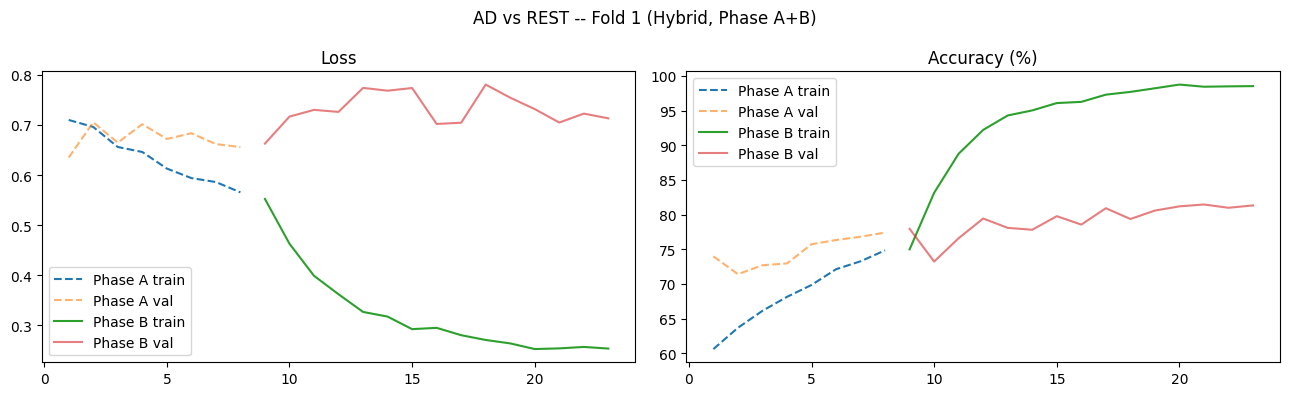

  Fold 1 -- Patient-level val acc: 82.14%

  --- Fold 2/5 ---
  Train -- AD: 982 | REST: 4795 | Val patients: 55


  AD vs REST -- Fold 2 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.6960 acc=62.4% | val loss=0.6736 acc=70.1%
    * Best val_acc=70.08% -- saved.


  AD vs REST -- Fold 2 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6678 acc=65.5% | val loss=0.7128 acc=66.3%


  AD vs REST -- Fold 2 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6439 acc=66.7% | val loss=0.6063 acc=80.3%
    * Best val_acc=80.26% -- saved.


  AD vs REST -- Fold 2 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6175 acc=69.9% | val loss=0.7323 acc=68.0%


...

  AD vs REST -- Fold 2 / Phase B Ep 05 | lr=9.43e-04 | train loss=0.3236 acc=94.2% | val loss=0.6184 acc=82.2%


  AD vs REST -- Fold 2 / Phase B Ep 06 | lr=8.74e-04 | train loss=0.3174 acc=94.8% | val loss=0.6084 acc=82.6%


  AD vs REST -- Fold 2 / Phase B Ep 07 | lr=7.84e-04 | train loss=0.2983 acc=96.2% | val loss=0.6310 acc=82.7%


  AD vs REST -- Fold 2 / Phase B Ep 08 | lr=6.77e-04 | train loss=0.2861 acc=96.3% | val loss=0.6403 acc=82.6%


  AD vs REST -- Fold 2 / Phase B Ep 09 | lr=5.60e-04 | train loss=0.2807 acc=96.8% | val loss=0.6174 acc=83.9%
    Early stopping at epoch 9.


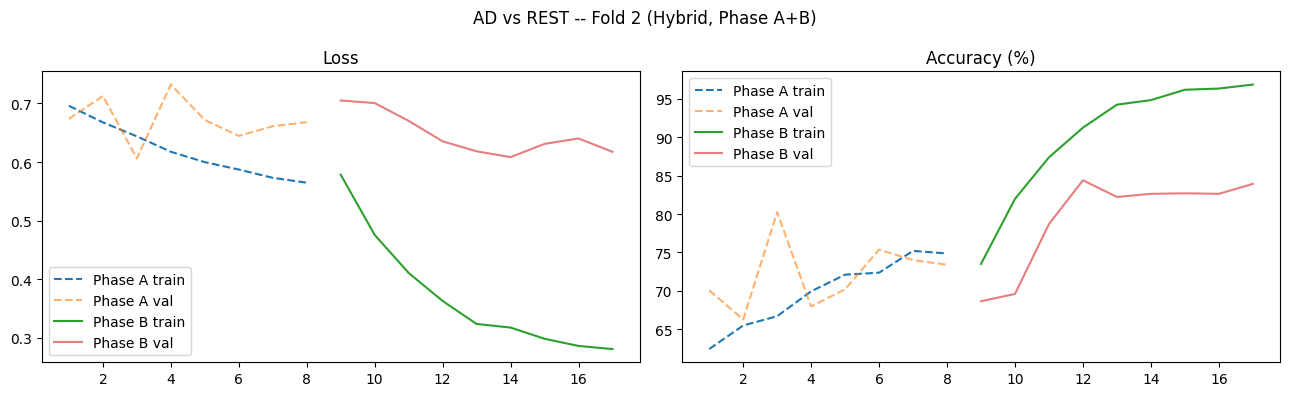

  Fold 2 -- Patient-level val acc: 89.09%

  --- Fold 3/5 ---
  Train -- AD: 977 | REST: 4828 | Val patients: 54


  AD vs REST -- Fold 3 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.6951 acc=63.5% | val loss=0.7782 acc=59.2%
    * Best val_acc=59.20% -- saved.


  AD vs REST -- Fold 3 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6713 acc=65.3% | val loss=0.6839 acc=71.1%
    * Best val_acc=71.09% -- saved.


  AD vs REST -- Fold 3 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6393 acc=67.2% | val loss=0.7054 acc=65.6%


  AD vs REST -- Fold 3 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6213 acc=68.8% | val loss=0.7634 acc=60.4%


...

  AD vs REST -- Fold 3 / Phase B Ep 08 | lr=6.77e-04 | train loss=0.2805 acc=96.7% | val loss=0.7177 acc=80.6%


  AD vs REST -- Fold 3 / Phase B Ep 09 | lr=5.60e-04 | train loss=0.2736 acc=97.5% | val loss=0.6905 acc=79.3%


  AD vs REST -- Fold 3 / Phase B Ep 10 | lr=4.40e-04 | train loss=0.2712 acc=97.9% | val loss=0.7616 acc=77.2%


  AD vs REST -- Fold 3 / Phase B Ep 11 | lr=3.23e-04 | train loss=0.2675 acc=97.7% | val loss=0.7127 acc=78.9%


  AD vs REST -- Fold 3 / Phase B Ep 12 | lr=2.16e-04 | train loss=0.2595 acc=98.3% | val loss=0.6694 acc=81.1%
    Early stopping at epoch 12.


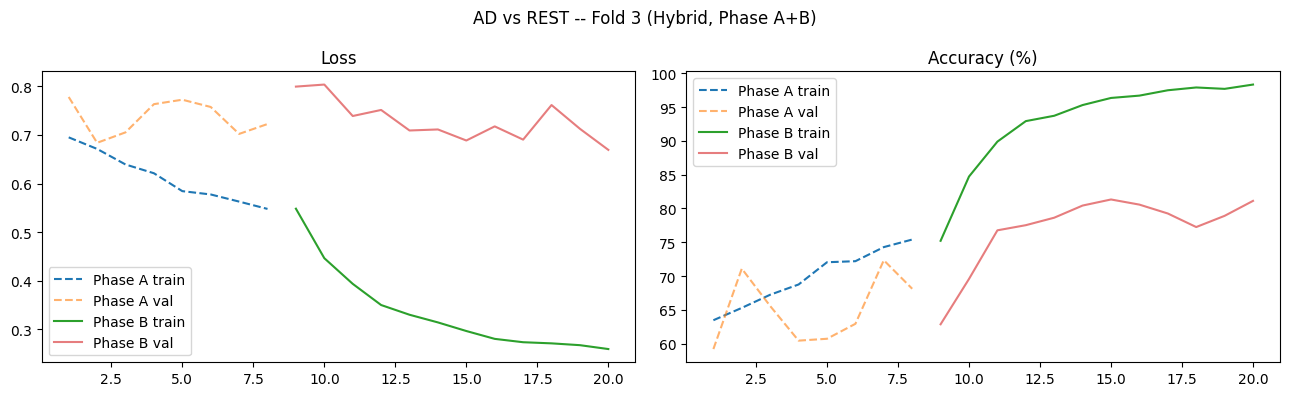

  Fold 3 -- Patient-level val acc: 81.48%

  --- Fold 4/5 ---
  Train -- AD: 977 | REST: 4845 | Val patients: 54


  AD vs REST -- Fold 4 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.6847 acc=63.8% | val loss=0.9004 acc=45.4%
    * Best val_acc=45.42% -- saved.


  AD vs REST -- Fold 4 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6637 acc=66.5% | val loss=0.8534 acc=42.8%


  AD vs REST -- Fold 4 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6261 acc=69.1% | val loss=0.7172 acc=68.5%
    * Best val_acc=68.51% -- saved.


  AD vs REST -- Fold 4 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.5952 acc=70.9% | val loss=0.8504 acc=55.1%


...

  AD vs REST -- Fold 4 / Phase B Ep 06 | lr=8.74e-04 | train loss=0.3005 acc=95.6% | val loss=1.0155 acc=68.1%


  AD vs REST -- Fold 4 / Phase B Ep 07 | lr=7.84e-04 | train loss=0.2855 acc=96.6% | val loss=0.9042 acc=69.8%


  AD vs REST -- Fold 4 / Phase B Ep 08 | lr=6.77e-04 | train loss=0.2800 acc=97.1% | val loss=0.8991 acc=70.7%


  AD vs REST -- Fold 4 / Phase B Ep 09 | lr=5.60e-04 | train loss=0.2657 acc=97.8% | val loss=0.9082 acc=72.4%


  AD vs REST -- Fold 4 / Phase B Ep 10 | lr=4.40e-04 | train loss=0.2686 acc=97.9% | val loss=0.8920 acc=71.9%
    Early stopping at epoch 10.


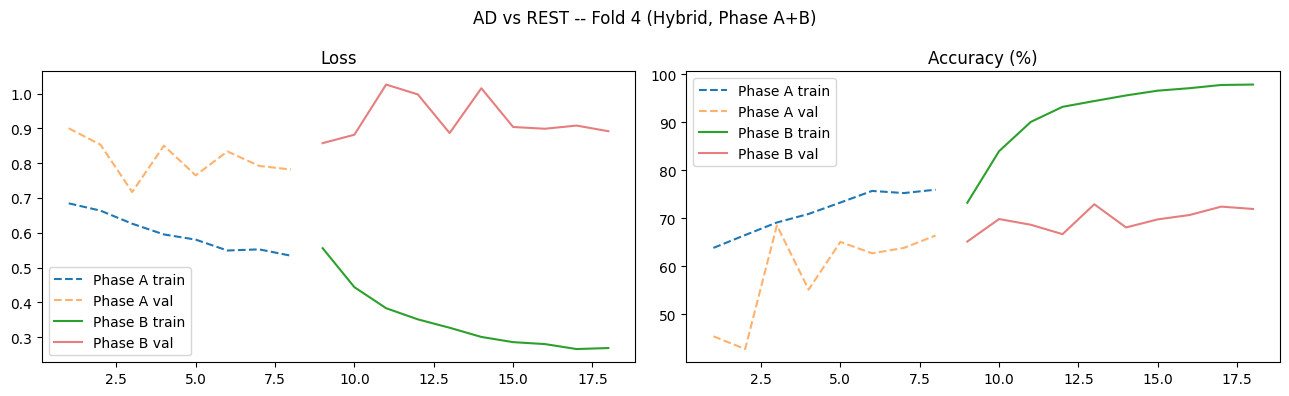

  Fold 4 -- Patient-level val acc: 77.78%

  --- Fold 5/5 ---
  Train -- AD: 975 | REST: 4857 | Val patients: 54


  AD vs REST -- Fold 5 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.7102 acc=62.6% | val loss=0.7549 acc=63.9%
    * Best val_acc=63.92% -- saved.


  AD vs REST -- Fold 5 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6620 acc=66.8% | val loss=0.7436 acc=65.5%
    * Best val_acc=65.47% -- saved.


  AD vs REST -- Fold 5 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6396 acc=69.1% | val loss=0.7519 acc=68.1%
    * Best val_acc=68.08% -- saved.


  AD vs REST -- Fold 5 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6157 acc=71.0% | val loss=0.7835 acc=62.2%


...

  AD vs REST -- Fold 5 / Phase B Ep 11 | lr=3.23e-04 | train loss=0.2603 acc=98.2% | val loss=0.7754 acc=74.3%


  AD vs REST -- Fold 5 / Phase B Ep 12 | lr=2.16e-04 | train loss=0.2580 acc=98.3% | val loss=0.7773 acc=75.4%


  AD vs REST -- Fold 5 / Phase B Ep 13 | lr=1.26e-04 | train loss=0.2589 acc=98.4% | val loss=0.7331 acc=77.3%
    * Best val_acc=77.31% -- saved.


  AD vs REST -- Fold 5 / Phase B Ep 14 | lr=5.73e-05 | train loss=0.2501 acc=98.7% | val loss=0.7273 acc=77.3%


  AD vs REST -- Fold 5 / Phase B Ep 15 | lr=1.45e-05 | train loss=0.2456 acc=98.9% | val loss=0.7648 acc=74.8%


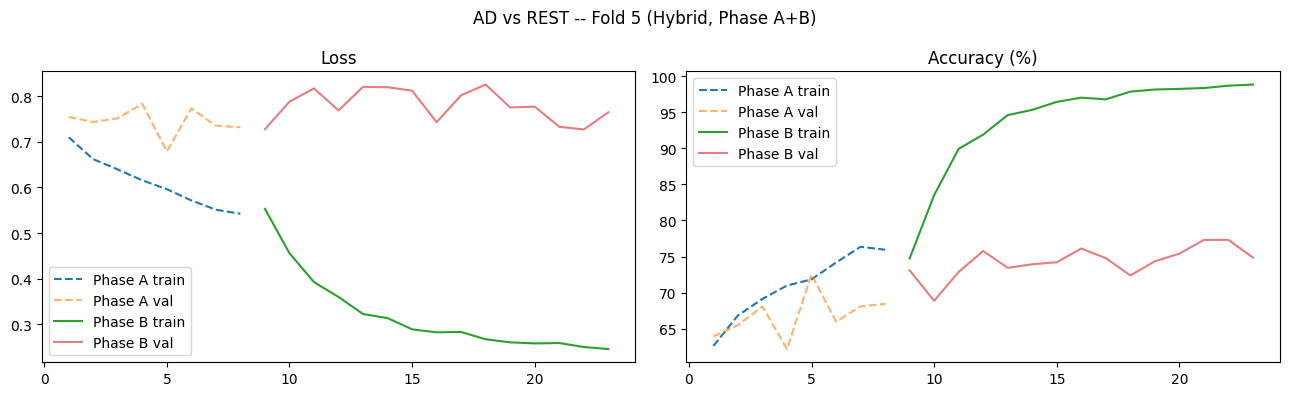

  Fold 5 -- Patient-level val acc: 81.48%

  AD vs REST -- CV: 82.39% +/- 3.68%

  CN vs REST  --  5-Fold CV  (ResNet18+DenseNet121 Hybrid)

  --- Fold 1/5 ---
  Train -- CN: 1593 | REST: 4175 | Val patients: 56


  CN vs REST -- Fold 1 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.6905 acc=59.6% | val loss=0.7407 acc=55.9%
    * Best val_acc=55.90% -- saved.


  CN vs REST -- Fold 1 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6631 acc=63.5% | val loss=0.6762 acc=70.9%
    * Best val_acc=70.87% -- saved.


  CN vs REST -- Fold 1 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6461 acc=64.6% | val loss=0.6752 acc=68.8%


  CN vs REST -- Fold 1 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6279 acc=65.8% | val loss=0.8020 acc=50.3%


...

  CN vs REST -- Fold 1 / Phase B Ep 01 | lr=5.00e-04 | train loss=0.5873 acc=70.8% | val loss=0.8746 acc=51.1%


  CN vs REST -- Fold 1 / Phase B Ep 02 | lr=1.00e-03 | train loss=0.4818 acc=78.8% | val loss=0.8036 acc=61.6%


  CN vs REST -- Fold 1 / Phase B Ep 03 | lr=1.00e-03 | train loss=0.3952 acc=85.5% | val loss=0.9633 acc=61.5%


  CN vs REST -- Fold 1 / Phase B Ep 04 | lr=9.85e-04 | train loss=0.3339 acc=89.8% | val loss=0.9805 acc=61.7%


  CN vs REST -- Fold 1 / Phase B Ep 05 | lr=9.43e-04 | train loss=0.3049 acc=92.2% | val loss=1.0355 acc=60.6%
    Early stopping at epoch 5.


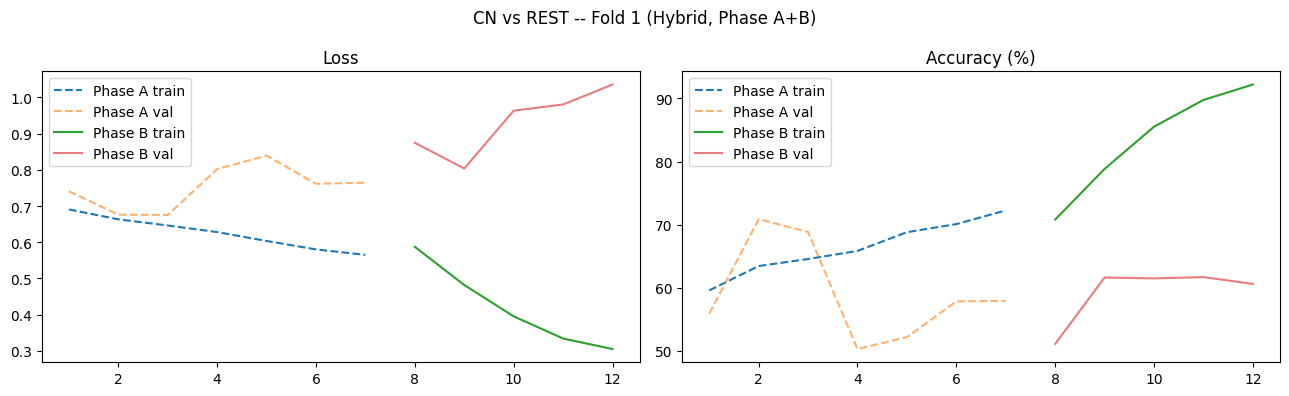

  Fold 1 -- Patient-level val acc: 73.21%

  --- Fold 2/5 ---
  Train -- CN: 1589 | REST: 4188 | Val patients: 55


  CN vs REST -- Fold 2 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.6898 acc=60.4% | val loss=0.6529 acc=67.1%
    * Best val_acc=67.10% -- saved.


  CN vs REST -- Fold 2 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6630 acc=62.9% | val loss=0.7824 acc=52.6%


  CN vs REST -- Fold 2 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6334 acc=65.7% | val loss=0.7048 acc=62.8%


  CN vs REST -- Fold 2 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6134 acc=68.0% | val loss=0.7124 acc=60.3%


...

  CN vs REST -- Fold 2 / Phase B Ep 01 | lr=5.00e-04 | train loss=0.5527 acc=72.1% | val loss=0.8519 acc=60.1%


  CN vs REST -- Fold 2 / Phase B Ep 02 | lr=1.00e-03 | train loss=0.4598 acc=80.0% | val loss=0.8008 acc=65.1%


  CN vs REST -- Fold 2 / Phase B Ep 03 | lr=1.00e-03 | train loss=0.3737 acc=86.8% | val loss=0.9962 acc=63.8%


  CN vs REST -- Fold 2 / Phase B Ep 04 | lr=9.85e-04 | train loss=0.3265 acc=90.8% | val loss=0.9715 acc=66.8%


  CN vs REST -- Fold 2 / Phase B Ep 05 | lr=9.43e-04 | train loss=0.2987 acc=92.7% | val loss=0.9715 acc=65.3%
    Early stopping at epoch 5.


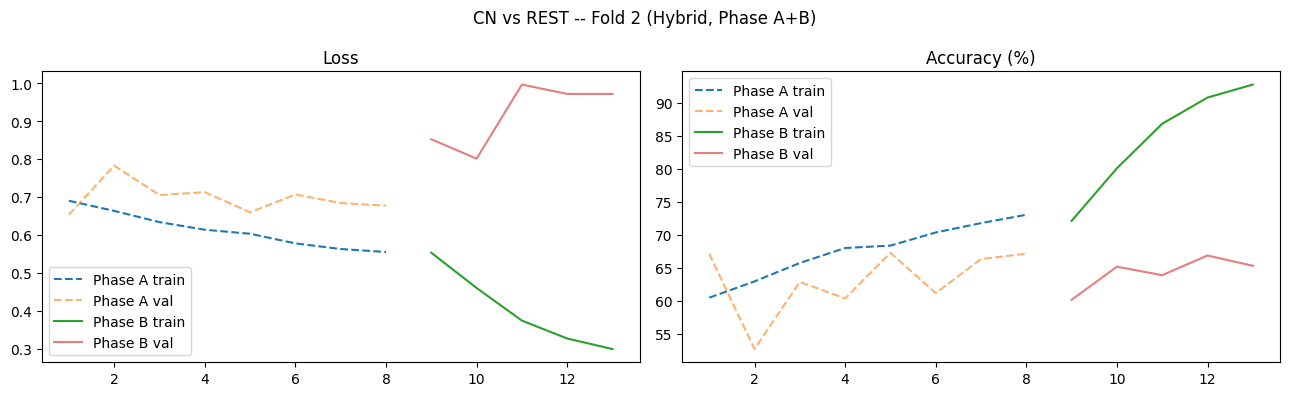

  Fold 2 -- Patient-level val acc: 74.55%

  --- Fold 3/5 ---
  Train -- CN: 1595 | REST: 4210 | Val patients: 54


  CN vs REST -- Fold 3 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.6997 acc=58.8% | val loss=0.7526 acc=51.1%
    * Best val_acc=51.11% -- saved.


  CN vs REST -- Fold 3 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6716 acc=62.1% | val loss=0.6683 acc=66.5%
    * Best val_acc=66.46% -- saved.


  CN vs REST -- Fold 3 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6606 acc=63.0% | val loss=0.6420 acc=69.5%
    * Best val_acc=69.50% -- saved.


  CN vs REST -- Fold 3 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6360 acc=64.6% | val loss=0.6522 acc=67.6%


...

  CN vs REST -- Fold 3 / Phase B Ep 04 | lr=9.85e-04 | train loss=0.3343 acc=89.9% | val loss=0.7943 acc=69.6%


  CN vs REST -- Fold 3 / Phase B Ep 05 | lr=9.43e-04 | train loss=0.3098 acc=92.0% | val loss=0.9777 acc=65.8%


  CN vs REST -- Fold 3 / Phase B Ep 06 | lr=8.74e-04 | train loss=0.2770 acc=93.5% | val loss=0.9100 acc=67.0%


  CN vs REST -- Fold 3 / Phase B Ep 07 | lr=7.84e-04 | train loss=0.2708 acc=94.3% | val loss=0.9531 acc=63.8%


  CN vs REST -- Fold 3 / Phase B Ep 08 | lr=6.77e-04 | train loss=0.2421 acc=95.6% | val loss=0.9396 acc=66.9%
    Early stopping at epoch 8.


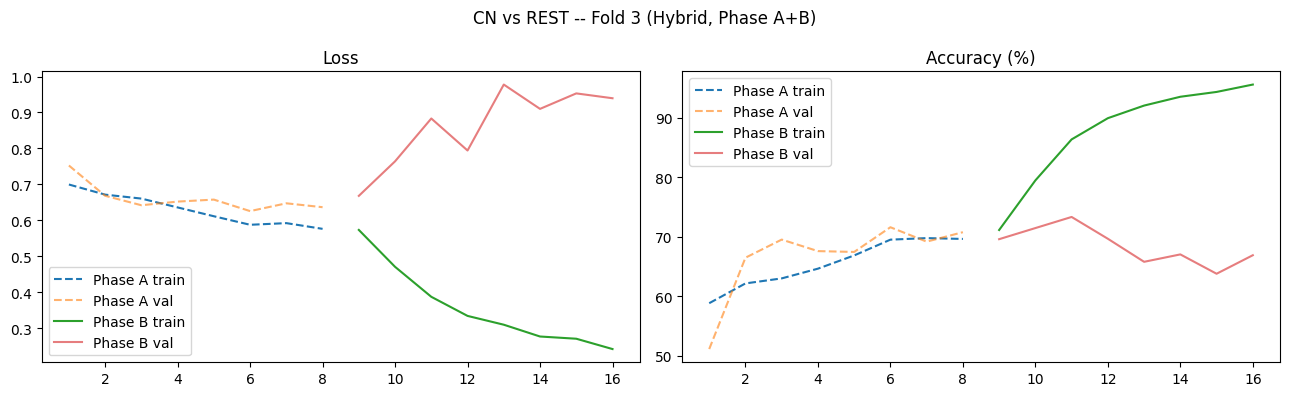

  Fold 3 -- Patient-level val acc: 75.93%

  --- Fold 4/5 ---
  Train -- CN: 1593 | REST: 4229 | Val patients: 54


  CN vs REST -- Fold 4 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.6977 acc=59.1% | val loss=0.6246 acc=67.7%
    * Best val_acc=67.74% -- saved.


  CN vs REST -- Fold 4 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6687 acc=62.7% | val loss=0.6451 acc=66.8%


  CN vs REST -- Fold 4 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6367 acc=66.6% | val loss=0.7675 acc=54.9%


  CN vs REST -- Fold 4 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6304 acc=65.4% | val loss=0.7206 acc=57.9%


...

  CN vs REST -- Fold 4 / Phase B Ep 01 | lr=5.00e-04 | train loss=0.5651 acc=70.9% | val loss=0.7714 acc=67.0%


  CN vs REST -- Fold 4 / Phase B Ep 02 | lr=1.00e-03 | train loss=0.4712 acc=79.6% | val loss=0.8364 acc=66.8%


  CN vs REST -- Fold 4 / Phase B Ep 03 | lr=1.00e-03 | train loss=0.3902 acc=86.3% | val loss=0.8939 acc=66.7%


  CN vs REST -- Fold 4 / Phase B Ep 04 | lr=9.85e-04 | train loss=0.3453 acc=89.3% | val loss=0.9186 acc=66.3%


  CN vs REST -- Fold 4 / Phase B Ep 05 | lr=9.43e-04 | train loss=0.3136 acc=91.8% | val loss=0.9569 acc=66.8%
    Early stopping at epoch 5.


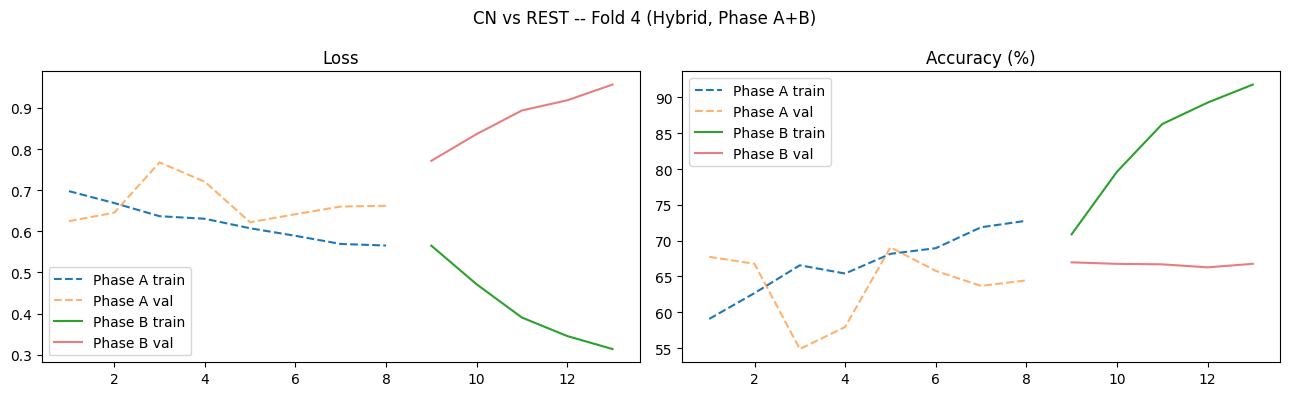

  Fold 4 -- Patient-level val acc: 74.07%

  --- Fold 5/5 ---
  Train -- CN: 1598 | REST: 4234 | Val patients: 54


  CN vs REST -- Fold 5 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.6927 acc=58.7% | val loss=0.6433 acc=65.6%
    * Best val_acc=65.61% -- saved.


  CN vs REST -- Fold 5 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6713 acc=62.1% | val loss=0.7151 acc=59.0%


  CN vs REST -- Fold 5 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6435 acc=64.8% | val loss=0.7988 acc=53.1%


  CN vs REST -- Fold 5 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6275 acc=66.4% | val loss=0.7137 acc=59.8%


...

  CN vs REST -- Fold 5 / Phase B Ep 06 | lr=8.74e-04 | train loss=0.2883 acc=92.8% | val loss=1.0541 acc=66.8%


  CN vs REST -- Fold 5 / Phase B Ep 07 | lr=7.84e-04 | train loss=0.2615 acc=94.8% | val loss=1.1521 acc=64.8%


  CN vs REST -- Fold 5 / Phase B Ep 08 | lr=6.77e-04 | train loss=0.2494 acc=95.5% | val loss=1.1973 acc=63.6%


  CN vs REST -- Fold 5 / Phase B Ep 09 | lr=5.60e-04 | train loss=0.2297 acc=96.7% | val loss=1.1646 acc=65.3%


  CN vs REST -- Fold 5 / Phase B Ep 10 | lr=4.40e-04 | train loss=0.2267 acc=96.3% | val loss=1.1184 acc=64.9%
    Early stopping at epoch 10.


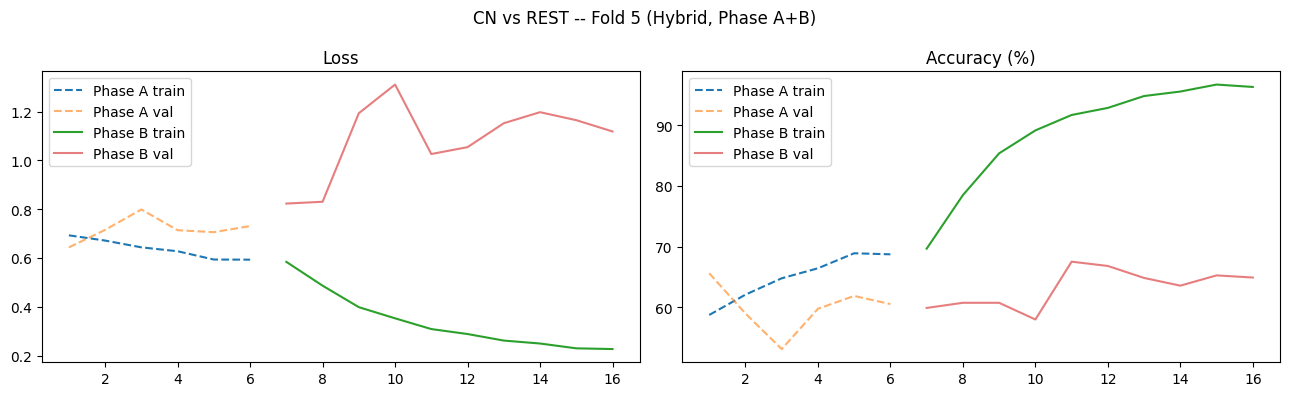

  Fold 5 -- Patient-level val acc: 66.67%

  CN vs REST -- CV: 72.89% +/- 3.23%

  MCI vs REST  --  5-Fold CV  (ResNet18+DenseNet121 Hybrid)

  --- Fold 1/5 ---
  Train -- MCI: 3214 | REST: 2554 | Val patients: 56


  MCI vs REST -- Fold 1 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.7081 acc=56.5% | val loss=0.7198 acc=50.4%
    * Best val_acc=50.37% -- saved.


  MCI vs REST -- Fold 1 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6859 acc=58.2% | val loss=0.7361 acc=48.6%


  MCI vs REST -- Fold 1 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6641 acc=62.1% | val loss=0.7754 acc=47.9%


  MCI vs REST -- Fold 1 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6507 acc=63.1% | val loss=0.7934 acc=45.8%


...

  MCI vs REST -- Fold 1 / Phase B Ep 03 | lr=1.00e-03 | train loss=0.4107 acc=83.4% | val loss=1.5176 acc=42.1%


  MCI vs REST -- Fold 1 / Phase B Ep 04 | lr=9.85e-04 | train loss=0.3415 acc=87.4% | val loss=1.3645 acc=51.1%


  MCI vs REST -- Fold 1 / Phase B Ep 05 | lr=9.43e-04 | train loss=0.3067 acc=90.3% | val loss=1.3758 acc=51.6%


  MCI vs REST -- Fold 1 / Phase B Ep 06 | lr=8.74e-04 | train loss=0.2779 acc=91.9% | val loss=1.3529 acc=52.8%


  MCI vs REST -- Fold 1 / Phase B Ep 07 | lr=7.84e-04 | train loss=0.2430 acc=94.1% | val loss=1.4196 acc=52.4%
    Early stopping at epoch 7.


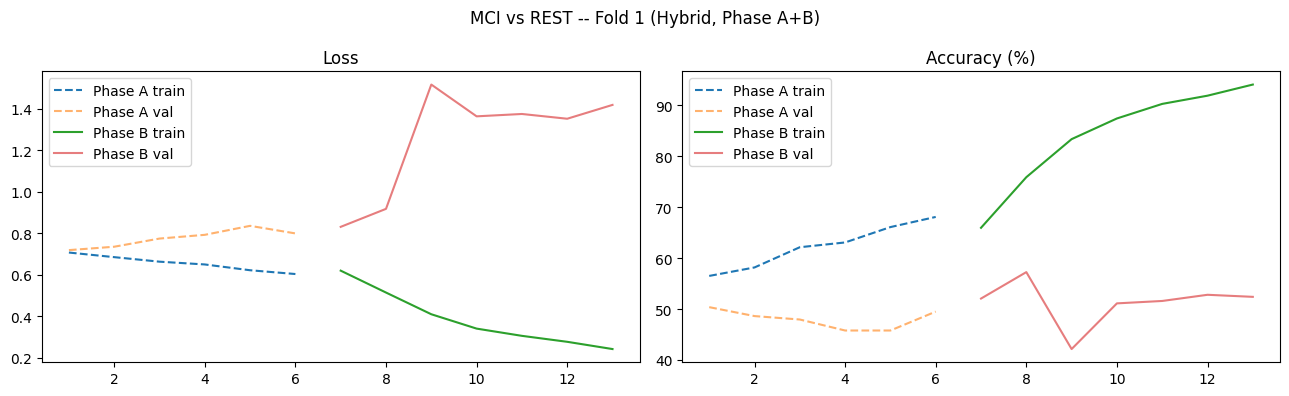

  Fold 1 -- Patient-level val acc: 57.14%

  --- Fold 2/5 ---
  Train -- MCI: 3206 | REST: 2571 | Val patients: 55


  MCI vs REST -- Fold 2 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.6982 acc=58.4% | val loss=0.7241 acc=53.2%
    * Best val_acc=53.19% -- saved.


  MCI vs REST -- Fold 2 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6755 acc=60.9% | val loss=0.7747 acc=47.6%


  MCI vs REST -- Fold 2 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6582 acc=62.4% | val loss=0.7159 acc=56.2%
    * Best val_acc=56.24% -- saved.


  MCI vs REST -- Fold 2 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6375 acc=63.9% | val loss=0.7105 acc=53.8%


...

  MCI vs REST -- Fold 2 / Phase B Ep 01 | lr=5.00e-04 | train loss=0.5986 acc=68.6% | val loss=0.8437 acc=51.7%


  MCI vs REST -- Fold 2 / Phase B Ep 02 | lr=1.00e-03 | train loss=0.4812 acc=78.3% | val loss=1.2422 acc=54.7%


  MCI vs REST -- Fold 2 / Phase B Ep 03 | lr=1.00e-03 | train loss=0.4003 acc=84.0% | val loss=1.1169 acc=53.7%


  MCI vs REST -- Fold 2 / Phase B Ep 04 | lr=9.85e-04 | train loss=0.3346 acc=88.6% | val loss=1.3666 acc=51.9%


  MCI vs REST -- Fold 2 / Phase B Ep 05 | lr=9.43e-04 | train loss=0.2936 acc=90.9% | val loss=1.3081 acc=53.5%
    Early stopping at epoch 5.


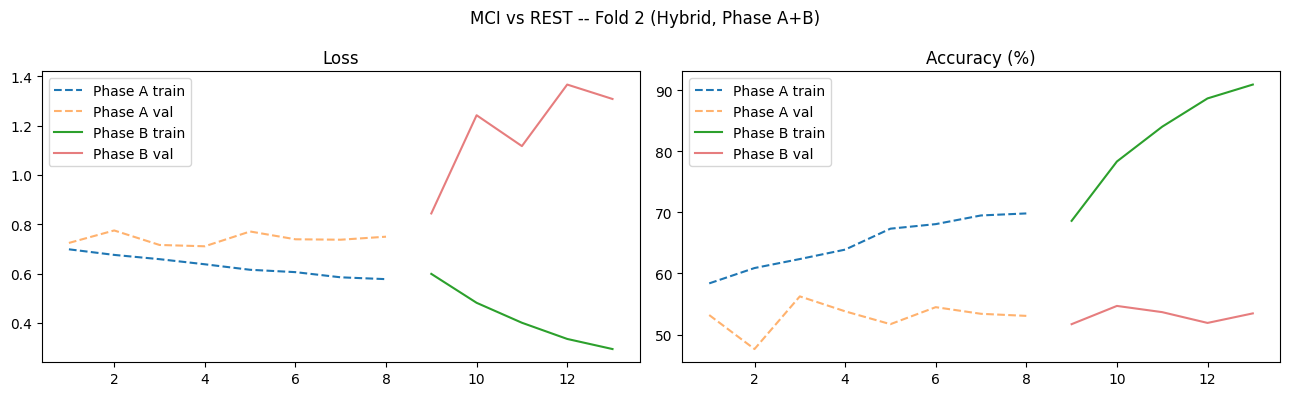

  Fold 2 -- Patient-level val acc: 58.18%

  --- Fold 3/5 ---
  Train -- MCI: 3233 | REST: 2572 | Val patients: 54


  MCI vs REST -- Fold 3 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.7034 acc=56.9% | val loss=0.7558 acc=45.8%
    * Best val_acc=45.78% -- saved.


  MCI vs REST -- Fold 3 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6776 acc=59.7% | val loss=0.7157 acc=54.5%
    * Best val_acc=54.50% -- saved.


  MCI vs REST -- Fold 3 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6704 acc=61.0% | val loss=0.7446 acc=45.2%


  MCI vs REST -- Fold 3 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6465 acc=63.9% | val loss=0.7408 acc=50.1%


...

  MCI vs REST -- Fold 3 / Phase B Ep 01 | lr=5.00e-04 | train loss=0.6204 acc=66.2% | val loss=0.8967 acc=48.1%


  MCI vs REST -- Fold 3 / Phase B Ep 02 | lr=1.00e-03 | train loss=0.5092 acc=76.0% | val loss=1.2149 acc=40.5%


  MCI vs REST -- Fold 3 / Phase B Ep 03 | lr=1.00e-03 | train loss=0.4131 acc=83.3% | val loss=1.2101 acc=46.5%


  MCI vs REST -- Fold 3 / Phase B Ep 04 | lr=9.85e-04 | train loss=0.3601 acc=86.8% | val loss=1.3389 acc=47.9%


  MCI vs REST -- Fold 3 / Phase B Ep 05 | lr=9.43e-04 | train loss=0.3138 acc=90.0% | val loss=1.4383 acc=43.5%
    Early stopping at epoch 5.


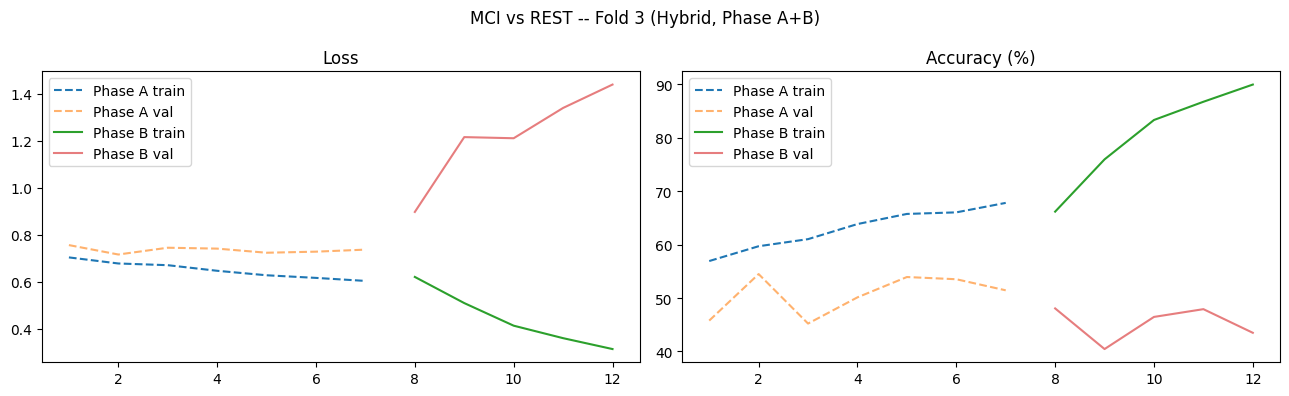

  Fold 3 -- Patient-level val acc: 59.26%

  --- Fold 4/5 ---
  Train -- MCI: 3252 | REST: 2570 | Val patients: 54


  MCI vs REST -- Fold 4 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.7158 acc=55.7% | val loss=0.6879 acc=53.4%
    * Best val_acc=53.39% -- saved.


  MCI vs REST -- Fold 4 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6901 acc=58.5% | val loss=0.7141 acc=52.7%


  MCI vs REST -- Fold 4 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6773 acc=61.2% | val loss=0.7057 acc=53.4%


  MCI vs REST -- Fold 4 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6573 acc=61.5% | val loss=0.6799 acc=56.8%
    * Best val_acc=56.82% -- saved.


...

  MCI vs REST -- Fold 4 / Phase B Ep 04 | lr=9.85e-04 | train loss=0.3534 acc=87.7% | val loss=0.9829 acc=59.8%


  MCI vs REST -- Fold 4 / Phase B Ep 05 | lr=9.43e-04 | train loss=0.3044 acc=90.4% | val loss=0.9651 acc=63.0%


  MCI vs REST -- Fold 4 / Phase B Ep 06 | lr=8.74e-04 | train loss=0.2783 acc=92.2% | val loss=1.0650 acc=57.7%


  MCI vs REST -- Fold 4 / Phase B Ep 07 | lr=7.84e-04 | train loss=0.2519 acc=94.1% | val loss=1.0620 acc=60.5%


  MCI vs REST -- Fold 4 / Phase B Ep 08 | lr=6.77e-04 | train loss=0.2419 acc=94.5% | val loss=1.0017 acc=60.0%
    Early stopping at epoch 8.


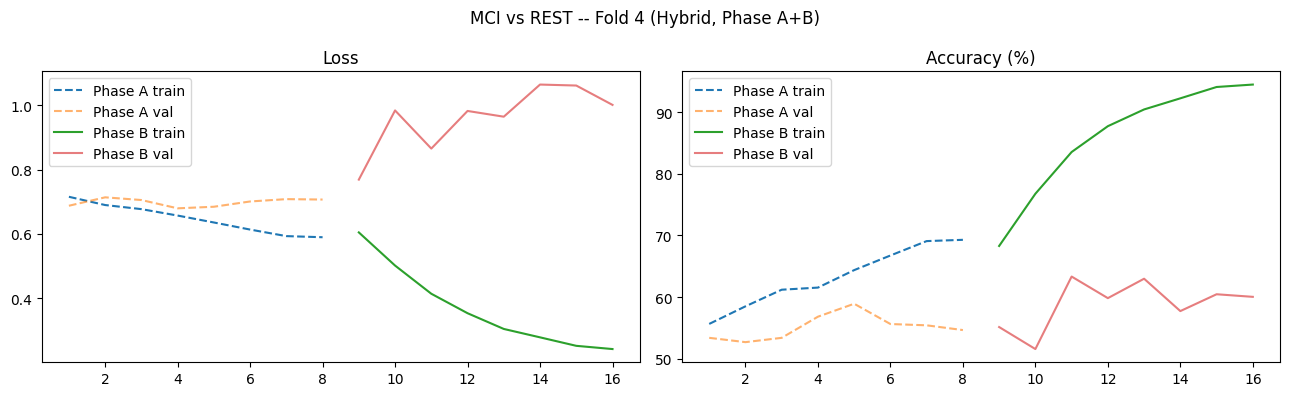

  Fold 4 -- Patient-level val acc: 70.37%

  --- Fold 5/5 ---
  Train -- MCI: 3259 | REST: 2573 | Val patients: 54


  MCI vs REST -- Fold 5 / Phase A Ep 01 | lr=1.50e-03 | train loss=0.7074 acc=57.1% | val loss=0.7539 acc=50.2%
    * Best val_acc=50.25% -- saved.


  MCI vs REST -- Fold 5 / Phase A Ep 02 | lr=3.00e-03 | train loss=0.6868 acc=59.4% | val loss=0.7641 acc=50.2%


  MCI vs REST -- Fold 5 / Phase A Ep 03 | lr=3.00e-03 | train loss=0.6640 acc=61.6% | val loss=0.7400 acc=50.0%


  MCI vs REST -- Fold 5 / Phase A Ep 04 | lr=2.80e-03 | train loss=0.6466 acc=63.0% | val loss=0.7235 acc=53.2%
    * Best val_acc=53.21% -- saved.


...

  MCI vs REST -- Fold 5 / Phase B Ep 01 | lr=5.00e-04 | train loss=0.6009 acc=68.6% | val loss=0.8525 acc=53.7%


  MCI vs REST -- Fold 5 / Phase B Ep 02 | lr=1.00e-03 | train loss=0.5088 acc=76.0% | val loss=0.9468 acc=54.1%


  MCI vs REST -- Fold 5 / Phase B Ep 03 | lr=1.00e-03 | train loss=0.4033 acc=84.5% | val loss=1.3211 acc=54.8%


  MCI vs REST -- Fold 5 / Phase B Ep 04 | lr=9.85e-04 | train loss=0.3460 acc=87.6% | val loss=1.1282 acc=56.4%


  MCI vs REST -- Fold 5 / Phase B Ep 05 | lr=9.43e-04 | train loss=0.3094 acc=90.3% | val loss=1.1698 acc=56.4%
    Early stopping at epoch 5.


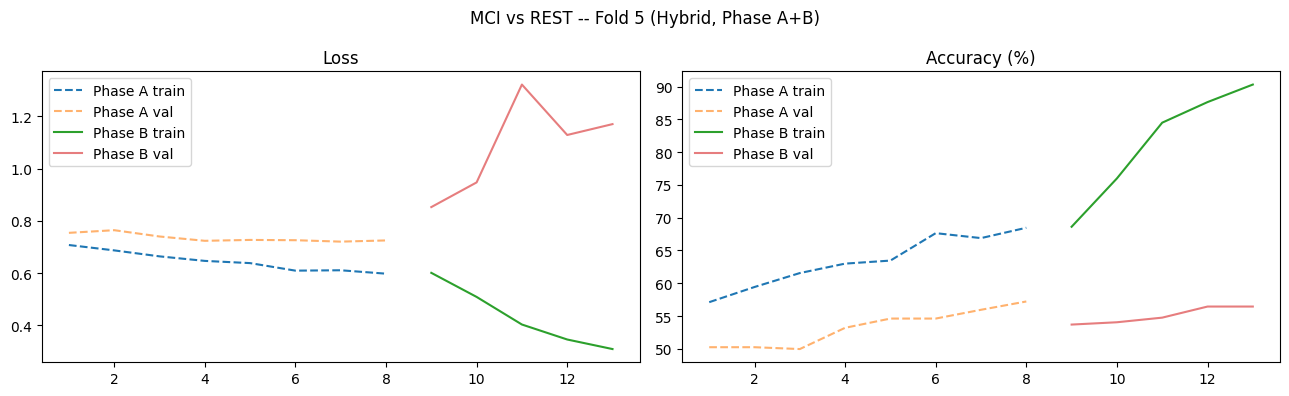

  Fold 5 -- Patient-level val acc: 59.26%

  MCI vs REST -- CV: 60.84% +/- 4.83%

All folds done.


In [16]:
trainval_by_class = defaultdict(list)
for pid in trainval_patients:
    trainval_by_class[clean_patients[pid]].append(pid)
for cls in CLASS_NAMES: random.shuffle(trainval_by_class[cls])

fold_results    = {cls: [] for cls in CLASS_NAMES}
all_fold_models = {cls: [] for cls in CLASS_NAMES}
all_fold_ckpts  = {cls: [] for cls in CLASS_NAMES}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    print(f'\n{"="*68}')
    print(f'  {pos_name} vs REST  --  {N_FOLDS}-Fold CV  (ResNet18+DenseNet121 Hybrid)')
    print(f'{"="*68}')

    class_folds = {cls: [trainval_by_class[cls][i::N_FOLDS] for i in range(N_FOLDS)]
                   for cls in CLASS_NAMES}

    for fold_idx in range(N_FOLDS):
        print(f'\n  --- Fold {fold_idx+1}/{N_FOLDS} ---')
        val_pids, train_pids = [], []
        for cls in CLASS_NAMES:
            for k, chunk in enumerate(class_folds[cls]):
                (val_pids if k == fold_idx else train_pids).extend(chunk)

        def expand(pids):
            out = []
            for pid in pids:
                c = clean_patients[pid]; l = CLASS_NAMES.index(c)
                for path in patient_slices[(pid, c)]: out.append((path, l, pid))
            return out

        def binarize(entries):
            return [(p, 1 if l == pos_class_idx else 0, pid) for p, l, pid in entries]

        train_bin = binarize(expand(train_pids))
        val_bin   = binarize(expand(val_pids))
        train_ds  = SliceDataset(train_bin, augment=True)
        val_ds    = SliceDataset(val_bin,   augment=False)

        if len(train_ds) == 0:
            raise RuntimeError(f'Fold {fold_idx+1} ({pos_name}): train_ds empty. Re-run Cell 7.')

        pos_count = sum(1 for _, l, _ in train_bin if l == 1)
        neg_count = len(train_bin) - pos_count
        print(f'  Train -- {pos_name}: {pos_count} | REST: {neg_count} | Val patients: {len(val_pids)}')

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=4, pin_memory=True, persistent_workers=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=4, pin_memory=True, persistent_workers=True)

        model = build_hybrid(num_classes=2).to(device)

        if USE_CLASS_WEIGHTED_CE:
            total_train = pos_count + neg_count
            class_weights = torch.tensor(
                [total_train / (2.0 * max(neg_count, 1)), total_train / (2.0 * max(pos_count, 1))],
                dtype=torch.float32, device=device)
            criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
        else:
            criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

        ckpt_path = os.path.join(CKPT_DIR, f'fold{fold_idx+1}_{pos_name}_vs_REST.pt')
        history, best_val_acc = train_two_phase(
            model, f'{pos_name} vs REST -- Fold {fold_idx+1}', ckpt_path,
            train_loader, val_loader, criterion)

        bh = history['phase_a']
        hb = history['phase_b']
        ep_a = range(1, len(bh['train_loss']) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle(f'{pos_name} vs REST -- Fold {fold_idx+1} (Hybrid, Phase A+B)')
        axes[0].plot(ep_a, bh['train_loss'], '--', label='Phase A train')
        axes[0].plot(ep_a, bh['val_loss'],   '--', alpha=0.6, label='Phase A val')
        if hb is not None:
            ep_b = range(len(bh['train_loss']) + 1, len(bh['train_loss']) + len(hb['train_loss']) + 1)
            axes[0].plot(ep_b, hb['train_loss'], label='Phase B train')
            axes[0].plot(ep_b, hb['val_loss'], alpha=0.6, label='Phase B val')
        axes[0].set_title('Loss'); axes[0].legend()
        axes[1].plot(ep_a, [a*100 for a in bh['train_acc']], '--', label='Phase A train')
        axes[1].plot(ep_a, [a*100 for a in bh['val_acc']],   '--', alpha=0.6, label='Phase A val')
        if hb is not None:
            axes[1].plot(ep_b, [a*100 for a in hb['train_acc']], label='Phase B train')
            axes[1].plot(ep_b, [a*100 for a in hb['val_acc']], alpha=0.6, label='Phase B val')
        axes[1].set_title('Accuracy (%)'); axes[1].legend()
        plt.tight_layout()
        plt.savefig(os.path.join(CKPT_DIR, f'curves_fold{fold_idx+1}_{pos_name}_vs_REST.png'), dpi=120)
        plt.show()

        pat_acc, _, _ = patient_level_eval(val_loader, model, num_classes=2)
        print(f'  Fold {fold_idx+1} -- Patient-level val acc: {pat_acc*100:.2f}%')
        fold_results[pos_name].append(pat_acc)
        all_fold_ckpts[pos_name].append(ckpt_path)
        model.to('cpu').eval(); all_fold_models[pos_name].append(model)
        del train_ds, val_ds; torch.cuda.empty_cache()

    print(f'\n  {pos_name} vs REST -- CV: '
          f'{np.mean(fold_results[pos_name])*100:.2f}% +/- {np.std(fold_results[pos_name])*100:.2f}%')

print('\nAll folds done.')


## Cell 12 — Weighted Ensemble Test Evaluation (Binary, Patient-Level, TTA)

  WEIGHTED ENSEMBLE -- HOLD-OUT TEST (Hybrid, Patient-Level)

  AD vs REST
    Fold 1: val_acc=82.14%  weight=0.1994
    Fold 2: val_acc=89.09%  weight=0.2163
    Fold 3: val_acc=81.48%  weight=0.1978
    Fold 4: val_acc=77.78%  weight=0.1888
    Fold 5: val_acc=81.48%  weight=0.1978



  Test Acc (AD vs REST): 82.98%  [47 patients]
              precision    recall  f1-score   support

        REST       0.88      0.92      0.90        39
          AD       0.50      0.38      0.43         8

    accuracy                           0.83        47
   macro avg       0.69      0.65      0.66        47
weighted avg       0.81      0.83      0.82        47



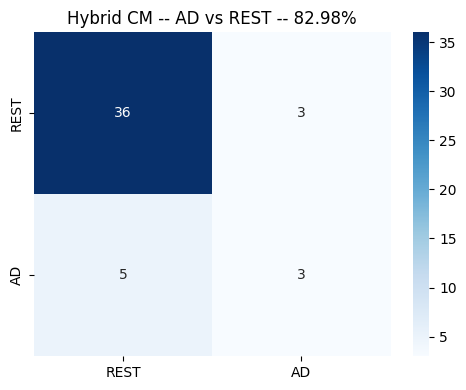


  CN vs REST
    Fold 1: val_acc=73.21%  weight=0.2009
    Fold 2: val_acc=74.55%  weight=0.2046
    Fold 3: val_acc=75.93%  weight=0.2083
    Fold 4: val_acc=74.07%  weight=0.2033
    Fold 5: val_acc=66.67%  weight=0.1829



  Test Acc (CN vs REST): 76.60%  [47 patients]
              precision    recall  f1-score   support

        REST       0.78      0.94      0.85        34
          CN       0.67      0.31      0.42        13

    accuracy                           0.77        47
   macro avg       0.72      0.62      0.64        47
weighted avg       0.75      0.77      0.73        47



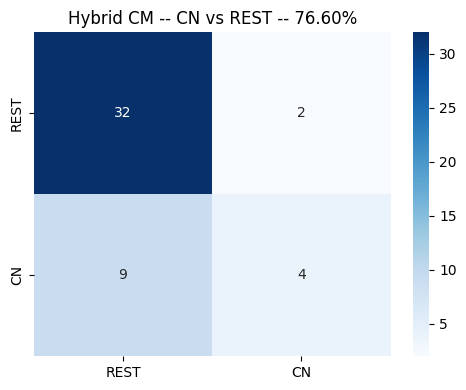


  MCI vs REST
    Fold 1: val_acc=57.14%  weight=0.1878
    Fold 2: val_acc=58.18%  weight=0.1913
    Fold 3: val_acc=59.26%  weight=0.1948
    Fold 4: val_acc=70.37%  weight=0.2313
    Fold 5: val_acc=59.26%  weight=0.1948



  Test Acc (MCI vs REST): 59.57%  [47 patients]
              precision    recall  f1-score   support

        REST       0.55      0.57      0.56        21
         MCI       0.64      0.62      0.63        26

    accuracy                           0.60        47
   macro avg       0.59      0.59      0.59        47
weighted avg       0.60      0.60      0.60        47



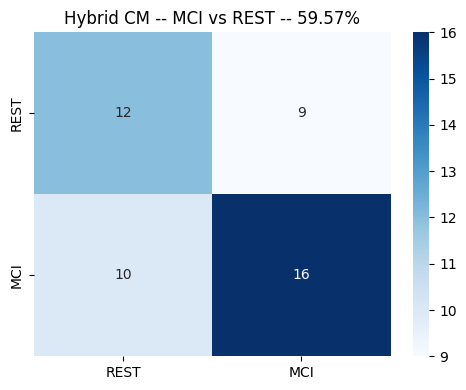

In [17]:
final_results = {}
print('='*68); print('  WEIGHTED ENSEMBLE -- HOLD-OUT TEST (Hybrid, Patient-Level)'); print('='*68)

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    binary_names = ['REST', pos_name]
    test_bin     = [(p, 1 if l == pos_class_idx else 0, pid) for p, l, pid in test_entries]
    test_ds      = SliceDataset(test_bin, augment=False)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True, persistent_workers=True)

    fold_accs    = np.array(fold_results[pos_name])
    fold_weights = fold_accs / fold_accs.sum()
    print(f'\n  {pos_name} vs REST')
    for fi, (acc, w) in enumerate(zip(fold_accs, fold_weights)):
        print(f'    Fold {fi+1}: val_acc={acc*100:.2f}%  weight={w:.4f}')

    fold_models = all_fold_models[pos_name]
    for m in fold_models: m.to(device).eval()

    dev_type = 'cuda' if device.type == 'cuda' else 'cpu'
    patient_probs  = defaultdict(lambda: np.zeros(2))
    patient_labels = {}
    with torch.no_grad():
        for images, labels, pids in tqdm(test_loader, desc=f'{pos_name} -- Ensemble', leave=False):
            images = images.to(device, non_blocking=True)
            batch_wp = np.zeros((images.size(0), 2))
            for fm, w in zip(fold_models, fold_weights):
                with torch.amp.autocast(device_type=dev_type, enabled=(device.type == 'cuda')):
                    logits = fm(images)
                    if TTA_HFLIP:
                        logits = logits + fm(torch.flip(images, dims=[-1]))
                batch_wp += w * torch.softmax(logits, dim=1).cpu().numpy()
            for wp, lbl, pid in zip(batch_wp, labels.numpy(), pids):
                patient_probs[pid] += wp; patient_labels[pid] = int(lbl)

    all_true, all_pred = [], []
    for pid, wp in patient_probs.items():
        all_true.append(patient_labels[pid]); all_pred.append(int(np.argmax(wp)))

    pat_acc = float(np.mean(np.array(all_true) == np.array(all_pred)))
    print(f'\n  Test Acc ({pos_name} vs REST): {pat_acc*100:.2f}%  [{len(patient_probs)} patients]')
    print(classification_report(all_true, all_pred, target_names=binary_names, zero_division=0))

    cm = confusion_matrix(all_true, all_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=binary_names, yticklabels=binary_names)
    plt.title(f'Hybrid CM -- {pos_name} vs REST -- {pat_acc*100:.2f}%')
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f'cm_{pos_name}_vs_REST.png'), dpi=150); plt.show()

    final_results[pos_name] = {
        'patient_test_acc': pat_acc,
        'cv_mean_acc': float(np.mean(fold_accs)),
        'cv_std_acc':  float(np.std(fold_accs)),
        'fold_weights': fold_weights.tolist(),
    }
    for m in fold_models: m.to('cpu')
    torch.cuda.empty_cache()


## Cell 13 — OVA Multi-Class Prediction on Hold-Out Test Set

  OVA MULTI-CLASS -- HOLD-OUT TEST (Hybrid)
  Accuracy: 63.83%  [47 patients]
              precision    recall  f1-score   support

          AD       0.56      0.62      0.59         8
          CN       0.67      0.31      0.42        13
         MCI       0.66      0.81      0.72        26

    accuracy                           0.64        47
   macro avg       0.63      0.58      0.58        47
weighted avg       0.64      0.64      0.62        47



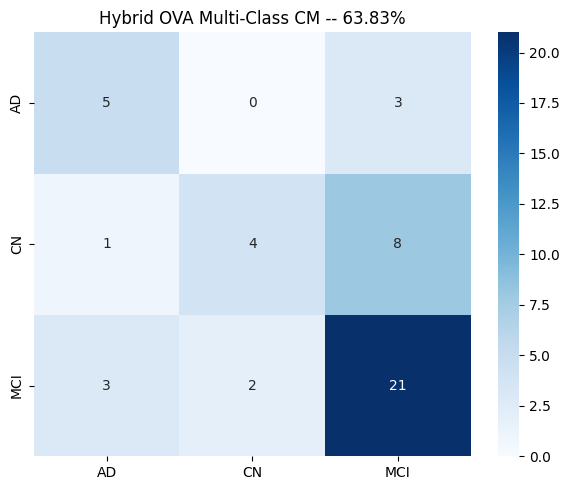

In [18]:
full_test_ds     = SliceDataset(test_entries, augment=False)
full_test_loader = DataLoader(full_test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True, persistent_workers=True)

dev_type = 'cuda' if device.type == 'cuda' else 'cpu'
ova_probs  = defaultdict(lambda: {c: 0.0 for c in CLASS_NAMES})
ova_labels = {}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    fold_accs    = np.array(fold_results[pos_name])
    fold_weights = fold_accs / fold_accs.sum()
    fold_models  = all_fold_models[pos_name]
    for m in fold_models: m.to(device).eval()
    with torch.no_grad():
        for images, labels, pids in tqdm(full_test_loader, desc=f'OVA [{pos_name}]', leave=False):
            images = images.to(device, non_blocking=True)
            batch_pos = np.zeros(images.size(0))
            for fm, w in zip(fold_models, fold_weights):
                with torch.amp.autocast(device_type=dev_type, enabled=(device.type == 'cuda')):
                    logits = fm(images)
                    if TTA_HFLIP:
                        logits = logits + fm(torch.flip(images, dims=[-1]))
                batch_pos += w * torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            for pos_p, lbl, pid in zip(batch_pos, labels.numpy(), pids):
                ova_probs[pid][pos_name] += float(pos_p); ova_labels[pid] = int(lbl)
    for m in fold_models: m.to('cpu')
    torch.cuda.empty_cache()

ova_true, ova_pred = [], []
for pid, conf in ova_probs.items():
    ova_pred.append(CLASS_NAMES.index(max(conf, key=conf.get)))
    ova_true.append(ova_labels[pid])

ova_acc = float(np.mean(np.array(ova_true) == np.array(ova_pred)))
print('='*68); print('  OVA MULTI-CLASS -- HOLD-OUT TEST (Hybrid)'); print('='*68)
print(f'  Accuracy: {ova_acc*100:.2f}%  [{len(ova_true)} patients]')
print(classification_report(ova_true, ova_pred, target_names=CLASS_NAMES, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(ova_true, ova_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Hybrid OVA Multi-Class CM -- {ova_acc*100:.2f}%')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'cm_ova_multiclass.png'), dpi=150); plt.show()


## Cell 14 — Final Summary & Export

  FINAL SUMMARY -- ResNet18+DenseNet121 Hybrid (Weighted Ensemble, 1-vs-All, Patient-Level)
  Class    CV Acc (mean+/-std)        Ensemble Test Acc
  ------------------------------------------------------------
  AD       82.39% +/- 3.68%           82.98%
  CN       72.89% +/- 3.23%           76.60%
  MCI      60.84% +/- 4.83%           59.57%

  OVA Multi-Class Test Acc: 63.83%  [47 patients]


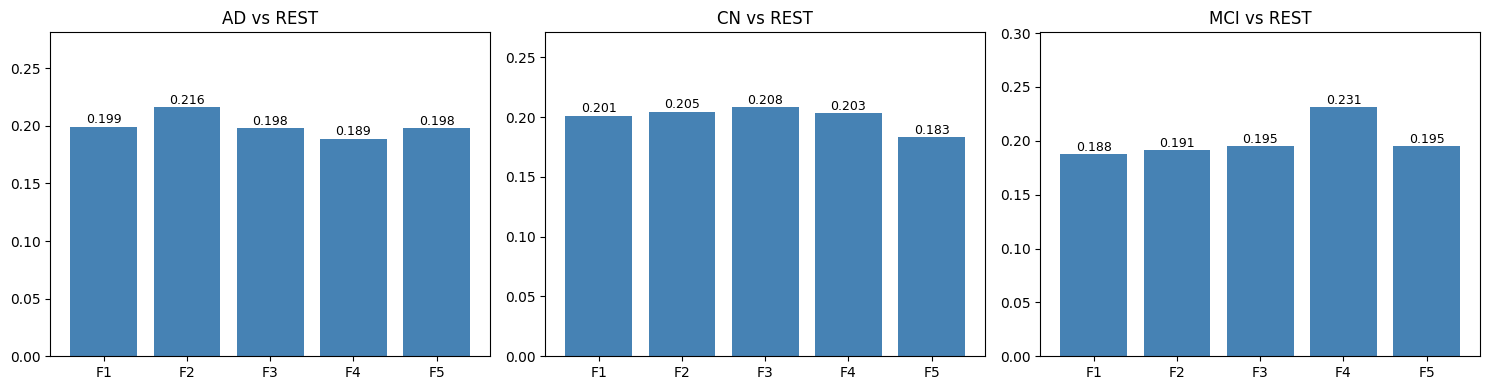

Results saved -> /kaggle/working/checkpoints_hybrid_rn18_dn121_patientlevel/results_hybrid_patientlevel.csv
Done!


In [19]:
print('='*72)
print('  FINAL SUMMARY -- ResNet18+DenseNet121 Hybrid (Weighted Ensemble, 1-vs-All, Patient-Level)')
print('='*72)
print(f'  {"Class":<8} {"CV Acc (mean+/-std)":<26} {"Ensemble Test Acc"}')
print(f'  {"-"*60}')
for cls, res in final_results.items():
    cv = f'{res["cv_mean_acc"]*100:.2f}% +/- {res["cv_std_acc"]*100:.2f}%'
    t  = f'{res["patient_test_acc"]*100:.2f}%'
    print(f'  {cls:<8} {cv:<26} {t}')
print(f'\n  OVA Multi-Class Test Acc: {ova_acc*100:.2f}%  [{len(ova_true)} patients]')
print('='*72)

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(5*len(CLASS_NAMES), 4))
for ax, cls in zip(axes, CLASS_NAMES):
    wts = final_results[cls]['fold_weights']
    ax.bar([f'F{i+1}' for i in range(len(wts))], wts, color='steelblue')
    ax.set_title(f'{cls} vs REST'); ax.set_ylim(0, max(wts)*1.3)
    for i, w in enumerate(wts): ax.text(i, w+0.003, f'{w:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'fold_weights.png'), dpi=120); plt.show()

csv_path = os.path.join(CKPT_DIR, 'results_hybrid_patientlevel.csv')
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=[
        'class','cv_mean_acc_%','cv_std_%','ensemble_test_acc_%','fold_weights','n_folds'])
    writer.writeheader()
    for cls, res in final_results.items():
        writer.writerow({'class': cls,
                         'cv_mean_acc_%':       round(res['cv_mean_acc']*100, 2),
                         'cv_std_%':            round(res['cv_std_acc']*100, 2),
                         'ensemble_test_acc_%': round(res['patient_test_acc']*100, 2),
                         'fold_weights':        str([round(w,4) for w in res['fold_weights']]),
                         'n_folds': N_FOLDS})
    writer.writerow({'class': 'OVA_MultiClass', 'cv_mean_acc_%': 'N/A', 'cv_std_%': 'N/A',
                     'ensemble_test_acc_%': round(ova_acc*100, 2),
                     'fold_weights': 'N/A', 'n_folds': N_FOLDS})
print(f'Results saved -> {csv_path}')
print('Done!')


## Cell 15 — Save Models & Weights

Consolidates all fold checkpoints into a single `hybrid_saved/` directory with a `metadata.json` (class names, image size, fold weights, val/test results) and zips everything for download.

**What is saved:**
- `{CLASS}_vs_REST_fold{N}.pt` — `state_dict` for each of the 15 fold models (3 classifiers × 5 folds)
- `metadata.json` — all config and results needed to reload without retraining

In [20]:
SAVE_DIR = '/kaggle/working/hybrid_saved'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Save each fold's state_dict ───────────────────────────────────────
for pos_name in CLASS_NAMES:
    for fold_idx, model in enumerate(all_fold_models[pos_name]):
        fname    = f'{pos_name}_vs_REST_fold{fold_idx+1}.pt'
        out_path = os.path.join(SAVE_DIR, fname)
        torch.save(model.state_dict(), out_path)
        size_mb = os.path.getsize(out_path) / 1e6
        print(f'Saved: {fname}  ({size_mb:.1f} MB)')

# ── 2. Save metadata JSON ────────────────────────────────────────────────
metadata = {
    'model':        'ResNet18+DenseNet121 Hybrid',
    'class_names':  CLASS_NAMES,
    'image_size':   IMAGE_SIZE,
    'preprocess_mode': PREPROCESS_MODE,
    'head_hidden':  HEAD_HIDDEN,
    'head_use_bn':  HEAD_USE_BN,
    'dropout':      DROPOUT,
    'n_folds':      N_FOLDS,
    'approach':     '1-vs-All binary classifiers, patient-level splitting',
    'fold_val_accs': {cls: fold_results[cls] for cls in CLASS_NAMES},
    'fold_weights':  {
        cls: (np.array(fold_results[cls]) /
              np.array(fold_results[cls]).sum()).tolist()
        for cls in CLASS_NAMES
    },
    'checkpoint_files': {
        cls: [f'{cls}_vs_REST_fold{k+1}.pt' for k in range(N_FOLDS)]
        for cls in CLASS_NAMES
    },
    'test_results': {
        cls: {
            'cv_mean_acc_%': round(res['cv_mean_acc'] * 100, 4),
            'cv_std_%':      round(res['cv_std_acc']  * 100, 4),
            'test_acc_%':    round(res['patient_test_acc'] * 100, 4),
        }
        for cls, res in final_results.items()
    },
    'ova_test_acc_%': round(ova_acc * 100, 4),
}

meta_path = os.path.join(SAVE_DIR, 'metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'\nSaved: metadata.json')

# ── 3. Zip everything for Kaggle download ────────────────────────────────
zip_path = '/kaggle/working/hybrid_saved'
shutil.make_archive(zip_path, 'zip', SAVE_DIR)
zip_size  = os.path.getsize(zip_path + '.zip') / 1e6
print(f'\nZipped -> hybrid_saved.zip  ({zip_size:.1f} MB)')
print('Download it from Kaggle Output panel.')


Saved: AD_vs_REST_fold1.pt  (75.6 MB)
Saved: AD_vs_REST_fold2.pt  (75.6 MB)
Saved: AD_vs_REST_fold3.pt  (75.6 MB)
Saved: AD_vs_REST_fold4.pt  (75.6 MB)
Saved: AD_vs_REST_fold5.pt  (75.6 MB)
Saved: CN_vs_REST_fold1.pt  (75.6 MB)
Saved: CN_vs_REST_fold2.pt  (75.6 MB)
Saved: CN_vs_REST_fold3.pt  (75.6 MB)
Saved: CN_vs_REST_fold4.pt  (75.6 MB)
Saved: CN_vs_REST_fold5.pt  (75.6 MB)
Saved: MCI_vs_REST_fold1.pt  (75.6 MB)
Saved: MCI_vs_REST_fold2.pt  (75.6 MB)
Saved: MCI_vs_REST_fold3.pt  (75.6 MB)
Saved: MCI_vs_REST_fold4.pt  (75.6 MB)
Saved: MCI_vs_REST_fold5.pt  (75.6 MB)

Saved: metadata.json

Zipped -> hybrid_saved.zip  (1052.8 MB)
Download it from Kaggle Output panel.


## Cell 16 — Reload Models for Inference

Run this cell (with `build_hybrid` defined in Cell 9) to reconstruct the full weighted ensemble from the saved checkpoints — no retraining needed.

In [21]:
SAVE_DIR = '/kaggle/working/hybrid_saved'

with open(os.path.join(SAVE_DIR, 'metadata.json')) as f:
    meta = json.load(f)

CLASS_NAMES_LOADED  = meta['class_names']
FOLD_WEIGHTS_LOADED = meta['fold_weights']

loaded_models = {}

for cls in CLASS_NAMES_LOADED:
    loaded_models[cls] = []
    for fname in meta['checkpoint_files'][cls]:
        m = build_hybrid(num_classes=2)
        m.load_state_dict(
            torch.load(os.path.join(SAVE_DIR, fname),
                       map_location=device, weights_only=True)
        )
        m.to(device).eval()
        loaded_models[cls].append(m)
    print(f'Loaded {N_FOLDS} fold-models for  {cls} vs REST')

print('\nAll models reloaded. Fold weights:')
for cls, wts in FOLD_WEIGHTS_LOADED.items():
    print(f'  {cls}: {[round(w,4) for w in wts]}')

print('\nStored results:')
for cls, res in meta['test_results'].items():
    print(f'  {cls:<6}: CV={res["cv_mean_acc_%"]}% '
          f'+/- {res["cv_std_%"]}%  |  Test={res["test_acc_%"]}%')
print(f'  OVA Multi-Class Test: {meta["ova_test_acc_%"]}%')


Loaded 5 fold-models for  AD vs REST
Loaded 5 fold-models for  CN vs REST
Loaded 5 fold-models for  MCI vs REST

All models reloaded. Fold weights:
  AD: [0.1994, 0.2163, 0.1978, 0.1888, 0.1978]
  CN: [0.2009, 0.2046, 0.2083, 0.2033, 0.1829]
  MCI: [0.1878, 0.1913, 0.1948, 0.2313, 0.1948]

Stored results:
  AD    : CV=82.3949% +/- 3.6847%  |  Test=82.9787%
  CN    : CV=72.8853% +/- 3.2309%  |  Test=76.5957%
  MCI   : CV=60.8427% +/- 4.8283%  |  Test=59.5745%
  OVA Multi-Class Test: 63.8298%


## XAI — Grad-CAM, Integrated Gradients, SHAP, LIME (OvA Ensemble)

All explanations are computed on the **validation-accuracy-weighted ensemble** of fold models for the positive class of each correctly-predicted sample, matching the ensemble-level XAI approach used in `Team_09_DAD_Net_Farida_Ali.ipynb`. Grad-CAM and Integrated Gradients target the ResNet-18 branch (`GRADCAM_TARGET`); switch to `'densenet'` to inspect the DenseNet-121 branch instead.

In [22]:
XAI_DIR = '/kaggle/working/hybrid_xai'
os.makedirs(XAI_DIR, exist_ok=True)

from captum.attr import IntegratedGradients, LayerGradCam

def _denorm(img_tensor):
    """Normalized (3,H,W) tensor -> (H,W,3) numpy in [0,1]."""
    mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    std  = np.array(IMAGENET_STD).reshape(3, 1, 1)
    arr  = img_tensor.detach().cpu().numpy() * std + mean
    return np.clip(np.transpose(arr, (1, 2, 0)), 0, 1)

def _ensemble_forward(batch_tensor, pos_class_idx):
    """Weighted-ensemble softmax probabilities (N, 2) for the OvA task `pos_class_idx`."""
    pos_name     = CLASS_NAMES[pos_class_idx]
    fold_wts     = np.array(fold_results[pos_name]); fold_wts = fold_wts / fold_wts.sum()
    fold_models  = all_fold_models[pos_name]
    batch_tensor = batch_tensor.to(device)
    probs = torch.zeros(batch_tensor.size(0), 2)
    with torch.no_grad():
        for fm, w in zip(fold_models, fold_wts):
            fm.to(device).eval()
            logits = fm(batch_tensor)
            probs += w * torch.softmax(logits, dim=1).cpu()
            fm.to('cpu')
    return probs

def _pick_samples(n_per_class=1):
    """Pick n_per_class correctly-predicted samples (by the OvA ensemble) from each class."""
    samples = {cls: [] for cls in CLASS_NAMES}
    for pid, conf in ova_probs.items():
        pred_name = max(conf, key=conf.get)
        true_idx  = ova_labels[pid]
        true_name = CLASS_NAMES[true_idx]
        if pred_name == true_name and len(samples[true_name]) < n_per_class:
            for imgs, lbls, pids in full_test_loader:
                for img, lbl, p in zip(imgs, lbls, pids):
                    if p == pid:
                        samples[true_name].append((img, true_idx, pid))
                        break
                if samples[true_name] and samples[true_name][-1][2] == pid:
                    break
        if all(len(v) >= n_per_class for v in samples.values()):
            break
    flat = []
    for cls, s_list in samples.items():
        print(f"  {cls}: {len(s_list)} sample(s) found")
        flat.extend(s_list)
    return flat

XAI_SAMPLES = _pick_samples(n_per_class=1)
print(f"\nTotal XAI samples: {len(XAI_SAMPLES)}")
for img, true_idx, pid in XAI_SAMPLES:
    pred_name = max(ova_probs[pid], key=ova_probs[pid].get)
    print(f"  PID: {pid} | True: {CLASS_NAMES[true_idx]} | Pred: {pred_name} | Conf: {ova_probs[pid]}")


  AD: 1 sample(s) found
  CN: 1 sample(s) found
  MCI: 1 sample(s) found

Total XAI samples: 3
  PID: 023_S_0916 | True: AD | Pred: AD | Conf: {'AD': 10.223519669878291, 'CN': 7.200236336231418, 'MCI': 9.729572753256654}
  PID: 141_S_6116 | True: CN | Pred: CN | Conf: {'AD': 0.38555448851211466, 'CN': 24.102207295097845, 'MCI': 7.310051062492123}
  PID: 052_S_6844 | True: MCI | Pred: MCI | Conf: {'AD': 4.360423494793426, 'CN': 5.0240816859939486, 'MCI': 13.725602114995622}


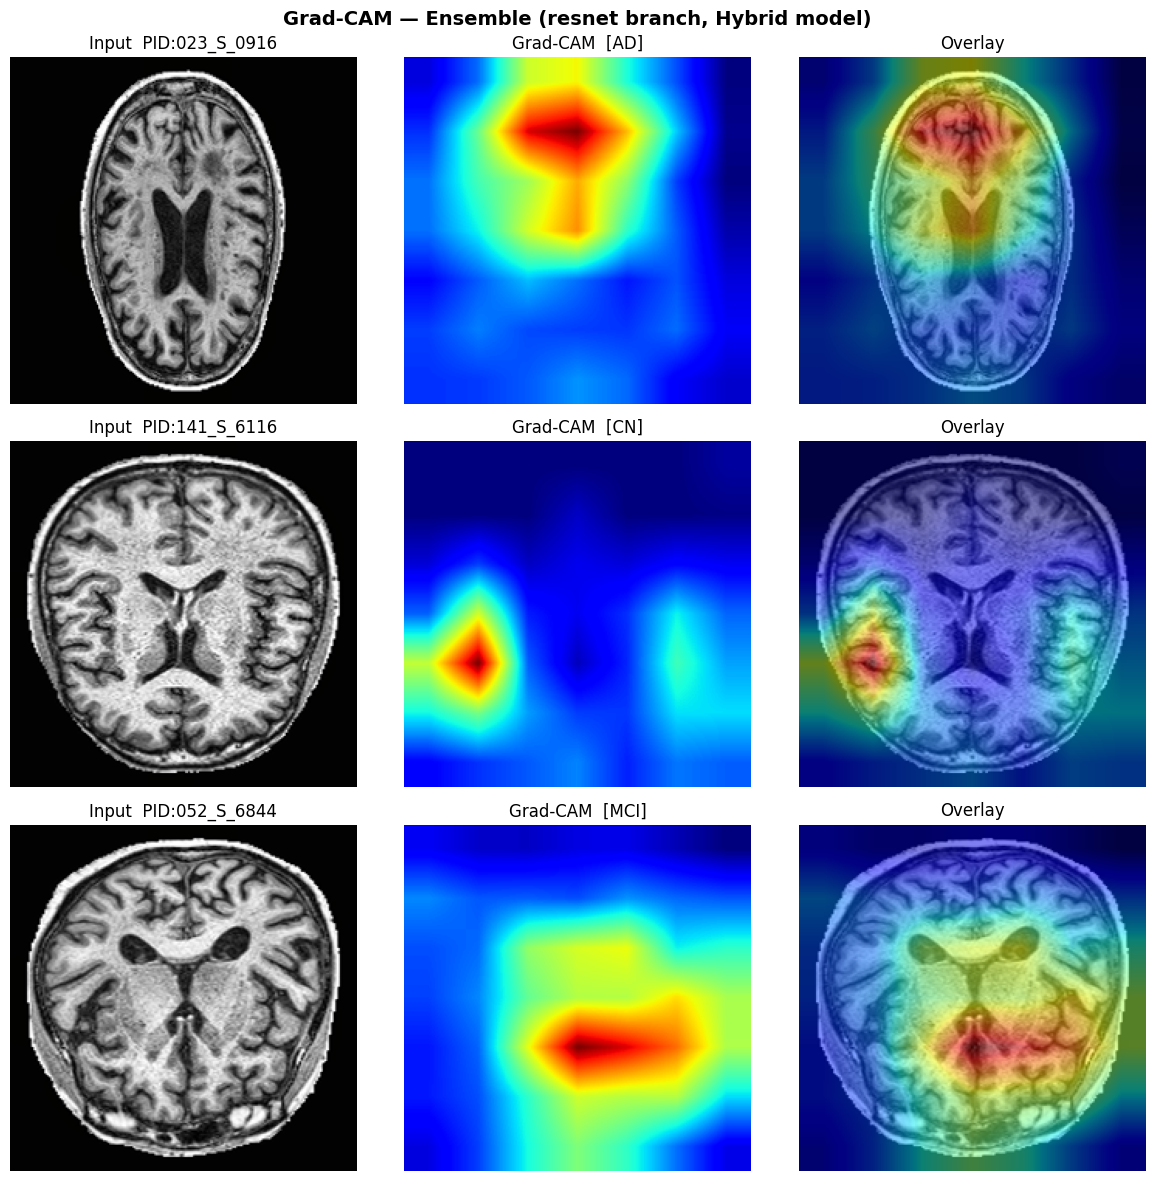

Saved -> hybrid_gradcam.png


In [23]:
# ── Grad-CAM (ensemble-weighted, captum LayerGradCam) ────────────────────────
def gradcam_ensemble(pos_name, img_tensor, target_class=1):
    fold_wts = np.array(fold_results[pos_name]); fold_wts = fold_wts / fold_wts.sum()
    cam_accum = np.zeros((IMAGE_SIZE, IMAGE_SIZE))
    for fm, w in zip(all_fold_models[pos_name], fold_wts):
        fm.to(device).eval()
        cam_layer = fm.densenet.features.denseblock4 if GRADCAM_TARGET == 'densenet' else fm.resnet.layer4[-1]
        lgc = LayerGradCam(fm, cam_layer)
        inp = img_tensor.unsqueeze(0).to(device).clone().detach().requires_grad_(True)
        cam_attr = lgc.attribute(inp, target=target_class)
        if isinstance(cam_attr, tuple): cam_attr = cam_attr[0]
        cam = F.relu(cam_attr.float().mean(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam_accum += w * cam
        fm.to('cpu')
    cam_accum = (cam_accum - cam_accum.min()) / (cam_accum.max() - cam_accum.min() + 1e-8)
    return cam_accum

fig, axes = plt.subplots(len(XAI_SAMPLES), 3, figsize=(12, 4 * len(XAI_SAMPLES)))
fig.suptitle(f'Grad-CAM — Ensemble ({GRADCAM_TARGET} branch, Hybrid model)', fontsize=14, fontweight='bold')

for row, (img, true_idx, pid) in enumerate(XAI_SAMPLES):
    pos_name  = CLASS_NAMES[true_idx]
    cam_accum = gradcam_ensemble(pos_name, img, target_class=1)
    raw   = _denorm(img)
    blend = 0.5 * raw + 0.5 * mpl_cm.jet(cam_accum)[..., :3]

    ax = axes[row] if len(XAI_SAMPLES) > 1 else axes
    ax[0].imshow(raw);                    ax[0].set_title(f'Input  PID:{pid[:10]}')
    ax[1].imshow(cam_accum, cmap='jet');  ax[1].set_title(f'Grad-CAM  [{pos_name}]')
    ax[2].imshow(blend);                  ax[2].set_title('Overlay')
    for a in ax: a.axis('off')

plt.tight_layout()
plt.savefig(f'{XAI_DIR}/hybrid_gradcam.png', dpi=150)
plt.show()
print('Saved -> hybrid_gradcam.png')


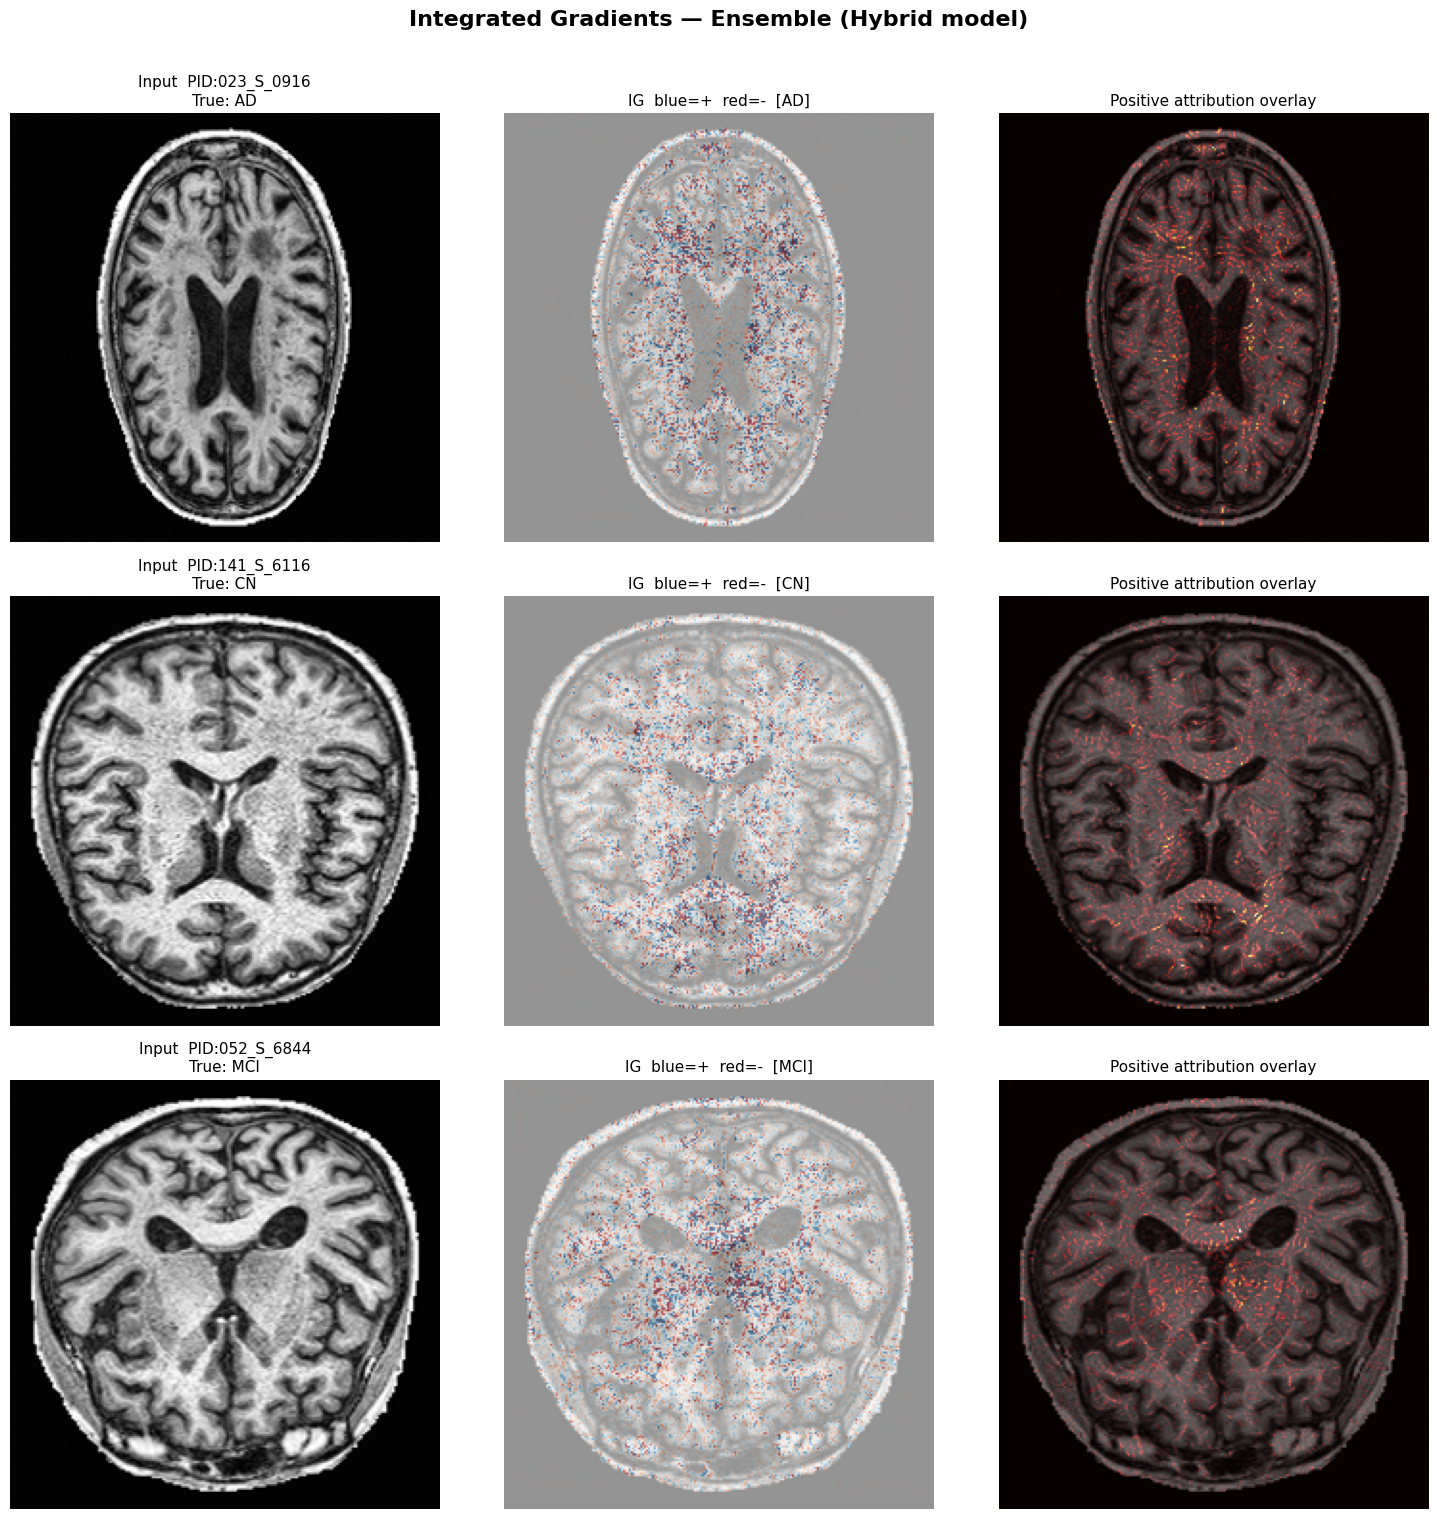

Saved -> hybrid_integrated_gradients.png


In [24]:
# ── Integrated Gradients (ensemble-weighted, captum) ─────────────────────────
_norm_ig    = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
baseline_ig = _norm_ig(torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)).unsqueeze(0).to(device)

fig, axes = plt.subplots(len(XAI_SAMPLES), 3, figsize=(15, 5 * len(XAI_SAMPLES)))
fig.suptitle('Integrated Gradients — Ensemble (Hybrid model)', fontsize=16, fontweight='bold', y=1.01)

for row, (img, true_idx, pid) in enumerate(XAI_SAMPLES):
    pos_name  = CLASS_NAMES[true_idx]
    fold_wts  = np.array(fold_results[pos_name]); fold_wts = fold_wts / fold_wts.sum()
    inp       = img.unsqueeze(0).to(device)

    ig_accum = np.zeros((IMAGE_SIZE, IMAGE_SIZE))
    for fm, w in zip(all_fold_models[pos_name], fold_wts):
        fm.to(device).eval()
        ig   = IntegratedGradients(fm)
        attr = ig.attribute(inp, baselines=baseline_ig, target=1, n_steps=32, internal_batch_size=8)
        ig_accum += w * attr.squeeze(0).mean(0).cpu().detach().numpy()
        fm.to('cpu')

    raw  = _denorm(img)
    gray = raw.mean(axis=-1)

    ax = axes[row] if len(XAI_SAMPLES) > 1 else axes
    ax[0].imshow(gray, cmap='gray', vmin=0, vmax=1)
    ax[0].set_title(f'Input  PID:{pid[:10]}\nTrue: {pos_name}', fontsize=11)

    vmax = np.percentile(np.abs(ig_accum), 99) + 1e-8
    ax[1].imshow(gray, cmap='gray', vmin=0, vmax=1)
    ax[1].imshow(ig_accum, cmap='RdBu_r', alpha=0.6, vmin=-vmax, vmax=vmax)
    ax[1].set_title(f'IG  blue=+  red=-  [{pos_name}]', fontsize=11)

    ig_pos = np.clip(ig_accum, 0, None); ig_pos = ig_pos / (ig_pos.max() + 1e-8)
    ax[2].imshow(gray, cmap='gray', vmin=0, vmax=1)
    ax[2].imshow(ig_pos, cmap='hot', alpha=0.6, vmin=0, vmax=1)
    ax[2].set_title('Positive attribution overlay', fontsize=11)

    for a in ax: a.axis('off')

plt.tight_layout()
plt.savefig(f'{XAI_DIR}/hybrid_integrated_gradients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> hybrid_integrated_gradients.png')


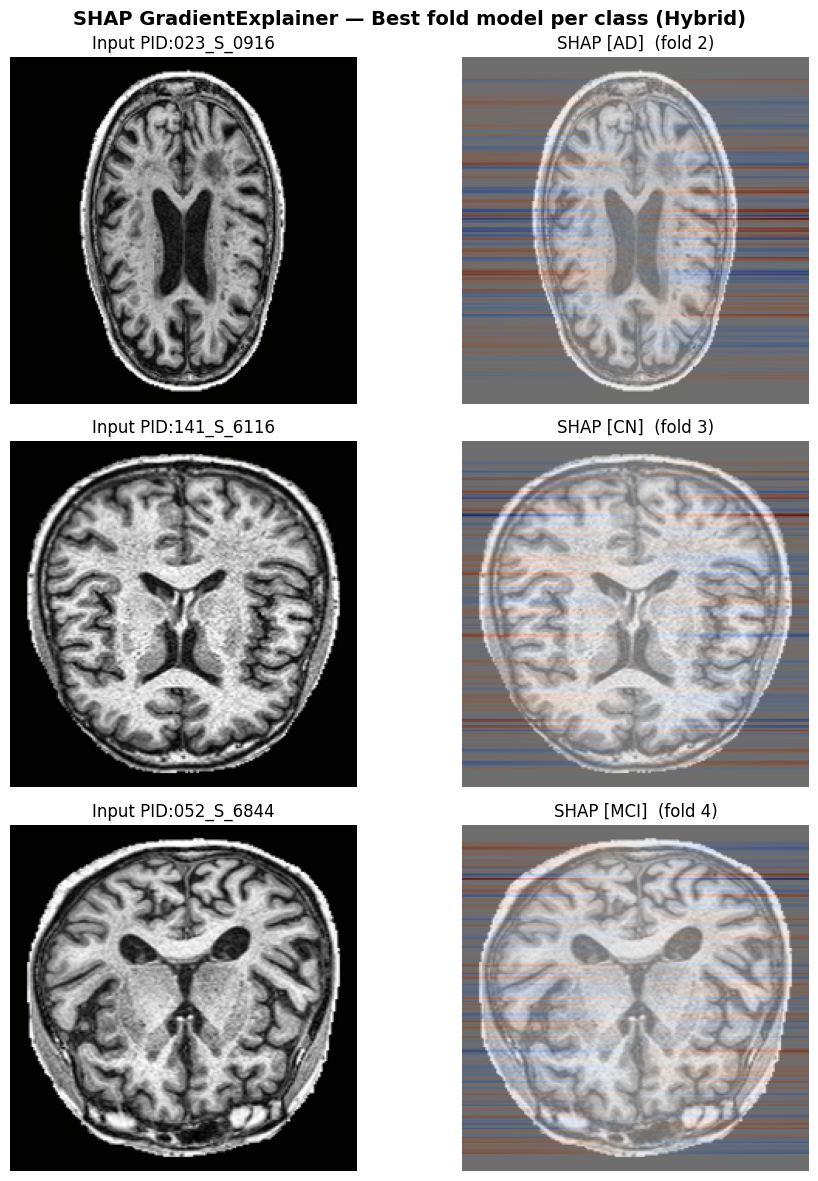

Saved -> hybrid_shap.png


In [25]:
# ── SHAP (best single fold per class — ensembling GradientExplainer is expensive) ─
import shap

fig, axes = plt.subplots(len(XAI_SAMPLES), 2, figsize=(10, 4 * len(XAI_SAMPLES)))
fig.suptitle('SHAP GradientExplainer — Best fold model per class (Hybrid)', fontsize=14, fontweight='bold')

for row, (img, true_idx, pid) in enumerate(XAI_SAMPLES):
    pos_name   = CLASS_NAMES[true_idx]
    best_fold  = int(np.argmax(fold_results[pos_name]))
    model      = all_fold_models[pos_name][best_fold].to(device).eval()

    bg_list, n_bg = [], 0
    bg_entries = [e for e in test_entries if e[2] != pid][:64]  # exclude the explained patient
    bg_ds = SliceDataset(bg_entries, augment=False)
    bg_loader = DataLoader(bg_ds, batch_size=8, shuffle=True, num_workers=0)
    for xb, _, _ in bg_loader:
        bg_list.append(xb); n_bg += xb.size(0)
        if n_bg >= SHAP_BG_SAMPLES: break
    background = torch.cat(bg_list, 0)[:SHAP_BG_SAMPLES].to(device).float() if bg_list else img.unsqueeze(0).to(device)
    if background.size(0) < 2:
        background = torch.cat([background, background], dim=0)

    xt = img.unsqueeze(0).clone().detach().to(device).requires_grad_(True)
    try:
        explainer = shap.GradientExplainer(model, background)
        sv = explainer.shap_values(xt)
        smap = np.asarray(sv[1][0] if isinstance(sv, list) else sv[0])
        if smap.ndim == 4: smap = smap[0]
        imp = smap.sum(axis=0)
        raw = _denorm(img)
        imp_resized = imp if imp.shape == raw.shape[:2] else np.array(
            Image.fromarray(imp).resize(raw.shape[:2][::-1])) if imp.ndim == 2 else imp
        vmax = np.abs(imp_resized).max() + 1e-8

        ax = axes[row] if len(XAI_SAMPLES) > 1 else axes
        ax[0].imshow(raw); ax[0].set_title(f'Input PID:{pid[:10]}'); ax[0].axis('off')
        ax[1].imshow(raw)
        ax[1].imshow(imp_resized, cmap='coolwarm', alpha=0.5, vmin=-vmax, vmax=vmax)
        ax[1].set_title(f'SHAP [{pos_name}]  (fold {best_fold+1})'); ax[1].axis('off')
    except Exception as e:
        print(f'  SHAP failed for {pos_name}: {e}')
    model.to('cpu')

plt.tight_layout()
plt.savefig(f'{XAI_DIR}/hybrid_shap.png', dpi=150)
plt.show()
print('Saved -> hybrid_shap.png')


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

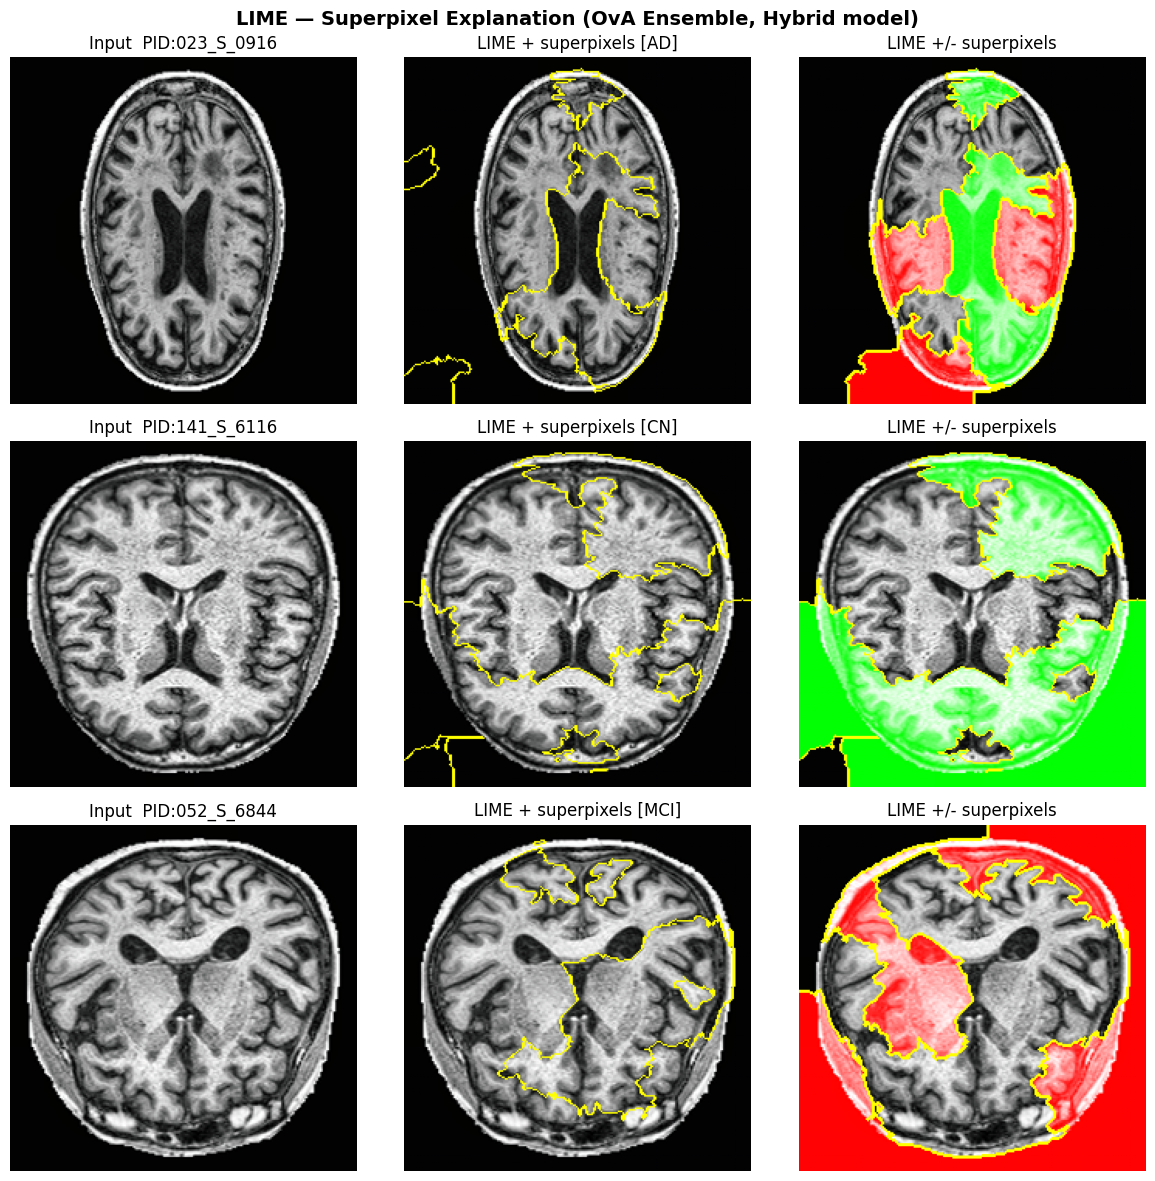

Saved -> hybrid_lime.png


In [26]:
# ── LIME (ensemble-weighted via _ensemble_forward) ───────────────────────────
from lime import lime_image
from skimage.segmentation import mark_boundaries

def lime_predict_fn(images_np, pos_class_idx):
    norm = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    tensors = []
    for img_np in images_np:
        t = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0
        tensors.append(norm(t))
    return _ensemble_forward(torch.stack(tensors), pos_class_idx).numpy()

explainer_lime = lime_image.LimeImageExplainer(random_state=42)

fig, axes = plt.subplots(len(XAI_SAMPLES), 3, figsize=(12, 4 * len(XAI_SAMPLES)))
fig.suptitle('LIME — Superpixel Explanation (OvA Ensemble, Hybrid model)', fontsize=14, fontweight='bold')

for row, (img, true_idx, pid) in enumerate(XAI_SAMPLES):
    pos_name = CLASS_NAMES[true_idx]
    raw_np   = (_denorm(img) * 255).astype(np.uint8)

    explanation = explainer_lime.explain_instance(
        raw_np,
        classifier_fn=lambda x: lime_predict_fn(x, true_idx),
        top_labels=2, hide_color=0,
        num_samples=LIME_NUM_SAMPLES,
        random_seed=42,
    )
    img_pos, mask_pos = explanation.get_image_and_mask(
        1, positive_only=True,  num_features=8, hide_rest=False)
    img_all, mask_all = explanation.get_image_and_mask(
        1, positive_only=False, num_features=8, hide_rest=False)

    ax = axes[row] if len(XAI_SAMPLES) > 1 else axes
    ax[0].imshow(raw_np)
    ax[0].set_title(f'Input  PID:{pid[:10]}')
    ax[1].imshow(mark_boundaries(img_pos / 255.0, mask_pos))
    ax[1].set_title(f'LIME + superpixels [{pos_name}]')
    ax[2].imshow(mark_boundaries(img_all / 255.0, mask_all))
    ax[2].set_title('LIME +/- superpixels')
    for a in ax: a.axis('off')

plt.tight_layout()
plt.savefig(f'{XAI_DIR}/hybrid_lime.png', dpi=150)
plt.show()
print('Saved -> hybrid_lime.png')


In [27]:
import os
import shutil
from IPython.display import FileLink, display

# ── Option A: zip everything in /kaggle/working ──────────────────────────
WORKING_DIR = '/kaggle/working'
ZIP_NAME    = '/kaggle/working/all_outputs'   # .zip added automatically

# Exclude the zip itself (and any previous zips) from being re-zipped into itself
def _zip_filter(dirpath, filenames):
    return [f for f in filenames if f.endswith('.zip')]

shutil.make_archive(
    base_name=ZIP_NAME,
    format='zip',
    root_dir=WORKING_DIR
)

zip_path = ZIP_NAME + '.zip'
size_mb  = os.path.getsize(zip_path) / 1e6
print(f'Zipped -> {zip_path}  ({size_mb:.1f} MB)')

display(FileLink(zip_path))

Zipped -> /kaggle/working/all_outputs.zip  (3922.3 MB)


/kaggle/working/all_outputs.zip